
**Cartpole with Homology**

Homology is a way to characterize shapes


<ol>
TDA, or topological data analysis is a type of manifold learning, a strategy to deal with curse of dimensionality.
<li> compute PD, a PD is a multiset of points $(birth_i, death_i)$. Distance from diagonal is importance of feature. Compare 2 PDs with Wasserstein or bottleneck distance. </li>
<li>$L_{\text{total}}(\theta)
= L_{\text{task}}(\theta) + \lambda \, L_{\text{topology}}\big(\text{PD}(f_\theta(x))\big)$</li>
<li>Train w surrogate loss, does not BackProp</li>
<li>Compare w and without topology loss. Store multiple episodes into 1 point cloud and comapare</li>
<li>$H_0$: the Oth homology group. Describes connectedness of components. Vietoris-Rips filtration is increasing the radious around the points to see how over iterations the connectedness grows.  Animation of clusters Increase epsilon to see how (l,d) tracks with epsilon</li>
<li>$H_1:$ animation of loops. See in locomotion cases, robotics. </li>
<li>Point Cloud distance (life,death). Use EMD or Wasserstein or Bottleneck distance to compare PCD. Increase epsilon to show animation to cluster.   </li>
<li>Persistent Landscapes, a hilbert space where representations arent points but vectors and can use geometric operations like angles, lengths and projections. Should represent higher order features than points. </li>

</ol>


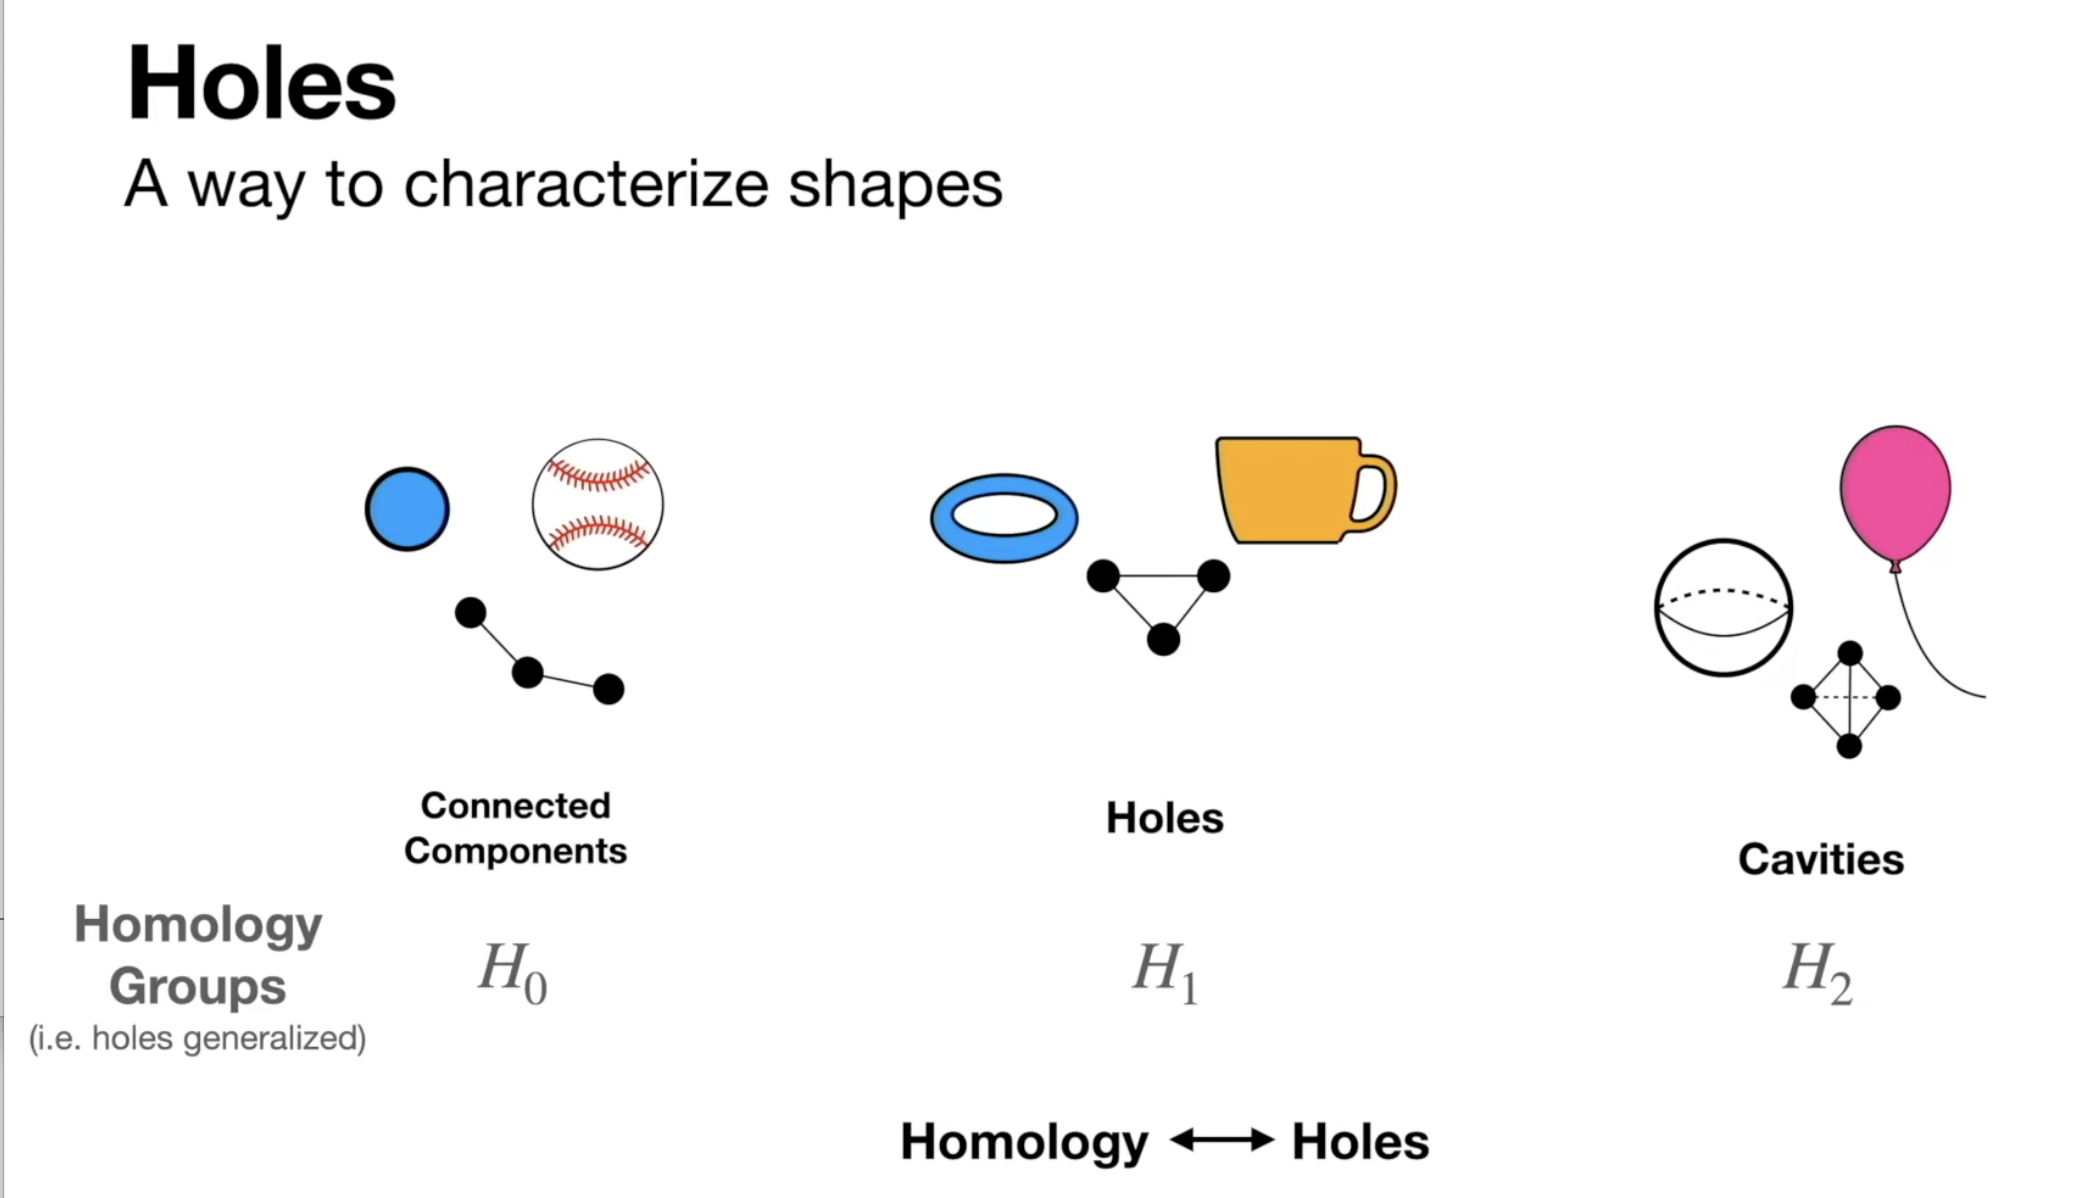#

Ho and H1: https://www.youtube.com/watch?v=w6Jx1vFp_Gk
Persistence graph


https://www.youtube.com/watch?v=8dF_ZtUTPRk
example
https://www.youtube.com/watch?v=OkDs9Wj5G1U

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/'Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
!pip install -q gymnasium[classic-control] torch


In [ ]:


import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo


num_eval_episodes = 4
env_name = "CartPole-v1"  # Replace with your environment

env = gym.make(env_name, render_mode='rgb_array')

env = RecordVideo(
    env,
    video_folder="cartpole-agent",    # Folder to save videos
    name_prefix="eval",               # Prefix for video filenames
    episode_trigger=lambda x: True    # Record every episode
)

env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)

print(f"Starting evaluation for {num_eval_episodes} episodes...")
print(f"Videos will be saved to: cartpole-agent/")
for idx in range(num_eval_episodes):
  obs, info = env.reset()

  episode_over = False
  episode_reward = 0
  count = 0

  while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)
    #print(observation, reward, terminated, truncated, info)
    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    episode_reward += reward
    episode_over = terminated or truncated

  print(f"Episode {idx} finished Total reward: {total_reward}")

env.close()

# [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
print(obs)
print(info)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/Colab Notebooks/cartpole-agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Starting evaluation for 4 episodes...
Videos will be saved to: cartpole-agent/
Episode 0 finished Total reward: 15.0
Episode 1 finished Total reward: 15.0
Episode 2 finished Total reward: 15.0
Episode 3 finished Total reward: 15.0
[ 0.03946544 -0.04365481 -0.00398729  0.0316842 ]
{'episode': {'r': 34.0, 'l': 34, 't': 0.14077}}


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 48.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/Colab Notebooks/cartpole-agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


Starting evaluation for 4 episodes...


<Figure size 1000x500 with 0 Axes>

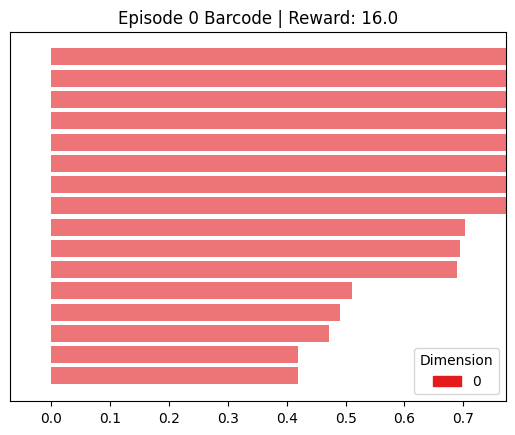

Episode 0 finished | Reward: 16.0 | H1 Loops: 0


<Figure size 1000x500 with 0 Axes>

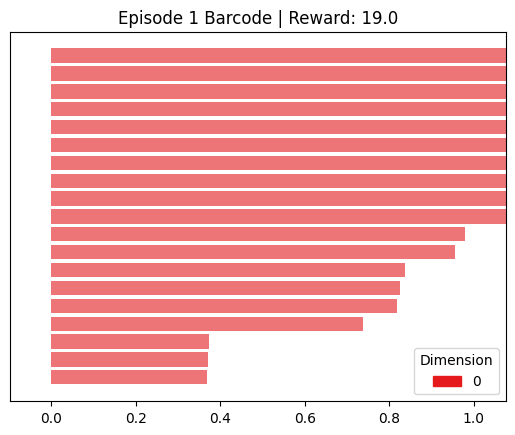

Episode 1 finished | Reward: 19.0 | H1 Loops: 0


<Figure size 1000x500 with 0 Axes>

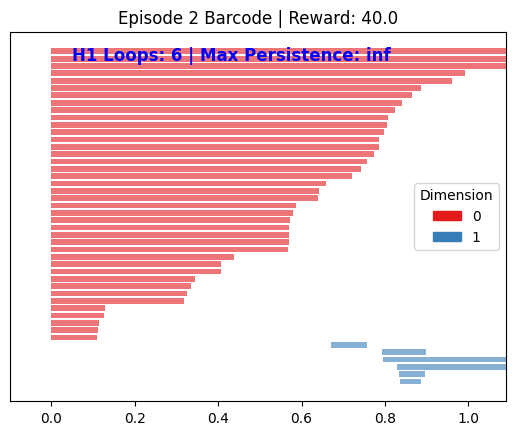

Episode 2 finished | Reward: 40.0 | H1 Loops: 6


<Figure size 1000x500 with 0 Axes>

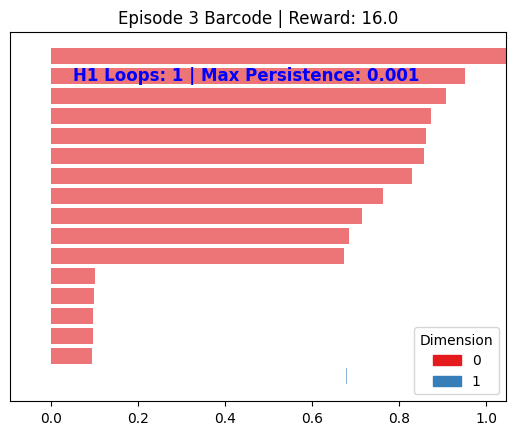

Episode 3 finished | Reward: 16.0 | H1 Loops: 1


In [ ]:
import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import gudhi.persistence_graphical_tools as gdplt
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from sklearn.preprocessing import StandardScaler

# --- 1. Robust TDA Function ---
def get_persistence_data(trajectory):
    if len(trajectory) < 10: # Increased slightly for better H1 detection
        return [], []

    # Standardize the 4D state space: [Pos, Vel, Angle, Ang_Vel]
    pts = StandardScaler().fit_transform(trajectory)

    # Build Rips Complex
    rips = gd.RipsComplex(points=pts, max_edge_length=1.0)
    stree = rips.create_simplex_tree(max_dimension=2)

    # Compute persistence
    diag = stree.persistence()

    # Extract H1 (loops) for logical analysis
    h1_sig = [p[1] for p in diag if p[0] == 1]

    return h1_sig, diag

# --- 2. Setup Environment ---
num_eval_episodes = 4
env_name = "CartPole-v1"
env = gym.make(env_name, render_mode='rgb_array')
env = RecordVideo(env, video_folder="cartpole-agent", name_prefix="eval", episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)

print(f"Starting evaluation for {num_eval_episodes} episodes...")

for idx in range(num_eval_episodes):
    obs, info = env.reset()
    episode_over = False
    trajectory = []

    while not episode_over:
        # Random action for demonstration
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)

        trajectory.append(observation)
        episode_over = terminated or truncated

    # --- 3. Post-Episode TDA Analysis ---
    trajectory_np = np.array(trajectory)
    h1_signature, full_diag = get_persistence_data(trajectory_np)

    if len(full_diag) > 0:
        # Create the Barcode Plot
        plt.figure(figsize=(10, 5))
        gdplt.plot_persistence_barcode(full_diag)

        # Calculate stats
        num_loops = len(h1_signature)
        reward = info['episode']['r']

        # Annotate plot
        plt.title(f"Episode {idx} Barcode | Reward: {reward}")
        if num_loops > 0:
            max_p = max([d - b for b, d in h1_signature])
            plt.text(0.05, 1.2, f"H1 Loops: {num_loops} | Max Persistence: {max_p:.3f}",
                     color='blue', fontsize=12, fontweight='bold')

        plt.show()

        print(f"Episode {idx} finished | Reward: {reward} | H1 Loops: {num_loops}")
    else:
        print(f"Episode {idx} was too short for TDA analysis.")

env.close()


In [ ]:
# ============================================================
# CartPole-v1 solved with REINFORCE (policy gradient)
# Single Colab cell
# ============================================================

!pip install -q gymnasium[classic-control] torch

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# -----------------------
# 1. Environment
# -----------------------
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]   # 4
n_actions = env.action_space.n            # 2

# -----------------------
# 2. Policy network (MLP)
# -----------------------
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)  # logits

    def act(self, obs):
        obs_t = torch.from_numpy(obs).float().unsqueeze(0)  # [1, obs_dim]
        logits = self.forward(obs_t)
        probs = torch.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs=probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob

policy = PolicyNet(obs_dim, n_actions)
optimizer = optim.Adam(policy.parameters(), lr=1e-2)
gamma = 0.99

# -----------------------
# 3. Train with REINFORCE
# -----------------------
def run_episode(env, policy):
    obs, _ = env.reset()
    done = False
    rewards = []
    log_probs = []

    while not done:
        action, log_prob = policy.act(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        rewards.append(reward)
        log_probs.append(log_prob)
        obs = next_obs

    return rewards, log_probs

def compute_returns(rewards, gamma=0.99):
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    returns = torch.tensor(returns, dtype=torch.float32)
    # normalize for stability
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns

n_episodes = 500
reward_history = []

for ep in range(1, n_episodes + 1):
    rewards, log_probs = run_episode(env, policy)
    returns = compute_returns(rewards, gamma)

    loss = 0.0
    for log_p, Gt in zip(log_probs, returns):
        loss += -log_p * Gt  # gradient ascent on expected return

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ep_reward = sum(rewards)
    reward_history.append(ep_reward)

    if len(reward_history) >= 100:
        avg_100 = np.mean(reward_history[-100:])
    else:
        avg_100 = np.mean(reward_history)

    if ep % 10 == 0:
        print(f"Episode {ep:4d} | Reward: {ep_reward:5.1f} | Avg(100): {avg_100:6.2f}")

    # CartPole-v1 is considered solved at avg reward >= 195 over last 100 episodes
    if avg_100 >= 195.0 and ep >= 100:
        print(f"\nEnvironment solved in {ep} episodes! Avg(100) = {avg_100:.2f}")
        break

env.close()
print("Training finished.")

Episode   10 | Reward:  21.0 | Avg(100):  32.20
Episode   20 | Reward:  38.0 | Avg(100):  35.20
Episode   30 | Reward:  36.0 | Avg(100):  37.30
Episode   40 | Reward:  30.0 | Avg(100):  42.02
Episode   50 | Reward:  66.0 | Avg(100):  48.24
Episode   60 | Reward: 140.0 | Avg(100):  56.75
Episode   70 | Reward: 284.0 | Avg(100):  71.17
Episode   80 | Reward: 141.0 | Avg(100):  82.59
Episode   90 | Reward: 178.0 | Avg(100):  99.01
Episode  100 | Reward:  71.0 | Avg(100):  96.84
Episode  110 | Reward:  48.0 | Avg(100):  99.31
Episode  120 | Reward:  89.0 | Avg(100): 103.10
Episode  130 | Reward: 500.0 | Avg(100): 130.04
Episode  140 | Reward: 500.0 | Avg(100): 174.42

Environment solved in 145 episodes! Avg(100) = 195.54
Training finished.


Torch Topology



In [ ]:
# ============================================
# Cell 1: Install dependencies & imports
# ============================================

!pip install -q gymnasium[classic-control] ripser persim torchvision

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import gymnasium as gym
from collections import deque

from ripser import ripser
from persim import plot_diagrams

import torchvision
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.5 MB/s eta 0:00:00
Using device: cpu


In [ ]:
# ============================================
# Cell 2: Topology-inspired surrogate loss
# ============================================

def pairwise_distances(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N, D]
    Returns [N, N] matrix of Euclidean distances.
    """
    diff = x.unsqueeze(1) - x.unsqueeze(0)  # [N, N, D]
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)
    return dist


def topology_surrogate_loss(x_in: torch.Tensor,
                            z_latent: torch.Tensor) -> torch.Tensor:
    """
    x_in:     [N, d_in]      (no grad needed)
    z_latent: [N, d_latent]  (grad flows here)

    Encourage latent pairwise distance structure to resemble input’s.
    This is a differentiable proxy for "topology preservation".
    """
    with torch.no_grad():
        D_in = pairwise_distances(x_in)            # [N, N]
        D_in = D_in / (D_in.max() + 1e-8)

    D_lat = pairwise_distances(z_latent)           # [N, N]
    D_lat = D_lat / (D_lat.max() + 1e-8)

    return F.mse_loss(D_lat, D_in)

/tmp/ipython-input-2584331454.py:93: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states_t = torch.tensor(states, dtype=torch.float32, device=device)


[topo=0e+00] Ep  20 | Return   17.0 | Avg20  17.40 | TopoLoss 0.0000
[topo=0e+00] Ep  40 | Return   13.0 | Avg20  15.80 | TopoLoss 0.0000
[topo=0e+00] Ep  60 | Return   22.0 | Avg20  21.60 | TopoLoss 0.0000
[topo=0e+00] Ep  80 | Return   25.0 | Avg20  25.35 | TopoLoss 0.0000
[topo=0e+00] Ep 100 | Return   15.0 | Avg20  19.15 | TopoLoss 0.0000
[topo=0e+00] Ep 120 | Return   29.0 | Avg20  22.05 | TopoLoss 0.0000
[topo=0e+00] Ep 140 | Return   25.0 | Avg20  20.00 | TopoLoss 0.0000
[topo=0e+00] Ep 160 | Return   15.0 | Avg20  24.35 | TopoLoss 0.0000
[topo=0e+00] Ep 180 | Return   10.0 | Avg20  17.65 | TopoLoss 0.0000
[topo=0e+00] Ep 200 | Return   13.0 | Avg20  14.80 | TopoLoss 0.0000
[topo=0e+00] Ep 220 | Return   10.0 | Avg20  13.40 | TopoLoss 0.0000
[topo=0e+00] Ep 240 | Return   29.0 | Avg20  14.70 | TopoLoss 0.0000
[topo=1e-02] Ep  20 | Return    8.0 | Avg20  17.70 | TopoLoss 0.0005
[topo=1e-02] Ep  40 | Return    8.0 | Avg20  14.05 | TopoLoss 0.0002
[topo=1e-02] Ep  60 | Return   15.

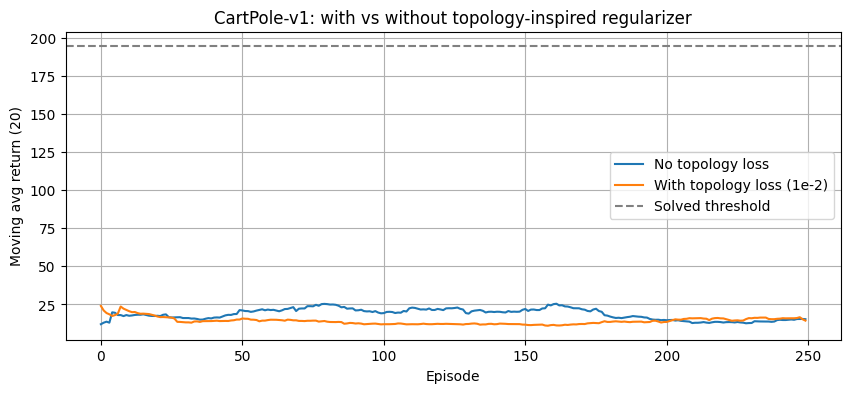

In [ ]:
# ============================================
# Cell 3: CartPole + topology-inspired loss
# ============================================

class CartPoleActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.value_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs):
        z = self.encoder(obs)
        logits = self.policy_head(z)
        value = self.value_head(z).squeeze(-1)
        return z, logits, value

    def act(self, obs_np):
        obs_t = torch.from_numpy(obs_np).float().unsqueeze(0).to(device)
        z, logits, value = self.forward(obs_t)
        probs = torch.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob, value.item(), z.detach().cpu().numpy()[0]


def train_cartpole(topology_weight=0.0,
                   n_episodes=300,
                   gamma=0.99,
                   print_every=20):
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    net = CartPoleActorCritic(obs_dim, n_actions).to(device)
    optim_net = optim.Adam(net.parameters(), lr=1e-3)

    ep_returns = []
    moving_avg = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        done = False

        log_probs = []
        values = []
        rewards = []
        states = []

        while not done:
            action, log_prob, value, z = net.act(obs)
            next_obs, r, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(torch.tensor(value, dtype=torch.float32, device=device))
            rewards.append(r)
            states.append(obs)

            obs = next_obs

        # returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32, device=device)

        values_t = torch.stack(values)
        advantages = returns - values_t.detach()

        log_probs_t = torch.stack(log_probs)
        policy_loss = -(log_probs_t * advantages).mean()
        value_loss = F.mse_loss(values_t, returns)

        # topology surrogate over this episode's states
        states_t = torch.tensor(states, dtype=torch.float32, device=device)
        z_latent, _, _ = net(states_t)
        topo_loss = topology_surrogate_loss(states_t.detach().view(states_t.size(0), -1),
                                            z_latent) if topology_weight > 0 else torch.tensor(0.0, device=device)

        loss = policy_loss + 0.5 * value_loss + topology_weight * topo_loss

        optim_net.zero_grad()
        loss.backward()
        optim_net.step()

        ep_ret = sum(rewards)
        ep_returns.append(ep_ret)
        avg20 = np.mean(ep_returns[-20:])
        moving_avg.append(avg20)

        if ep % print_every == 0:
            print(f"[topo={topology_weight:.0e}] Ep {ep:3d} | "
                  f"Return {ep_ret:6.1f} | Avg20 {avg20:6.2f} | "
                  f"TopoLoss {topo_loss.item():.4f}")

    env.close()
    return net, ep_returns, moving_avg


# --- Run ablation: no topology vs with topology ---
net_no_topo, ret_no_topo, ma_no_topo = train_cartpole(topology_weight=0.0, n_episodes=250)
net_topo, ret_topo, ma_topo = train_cartpole(topology_weight=1e-2, n_episodes=250)

plt.figure(figsize=(10,4))
plt.plot(ma_no_topo, label="No topology loss")
plt.plot(ma_topo, label="With topology loss (1e-2)")
plt.axhline(195, color="gray", linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Moving avg return (20)")
plt.title("CartPole-v1: with vs without topology-inspired regularizer")
plt.grid(True)
plt.legend()
plt.show()

Collected latent points: (93, 2)
Example episode returns: [9.0, 8.0, 10.0, 9.0, 9.0, 10.0, 10.0, 10.0, 8.0, 10.0]


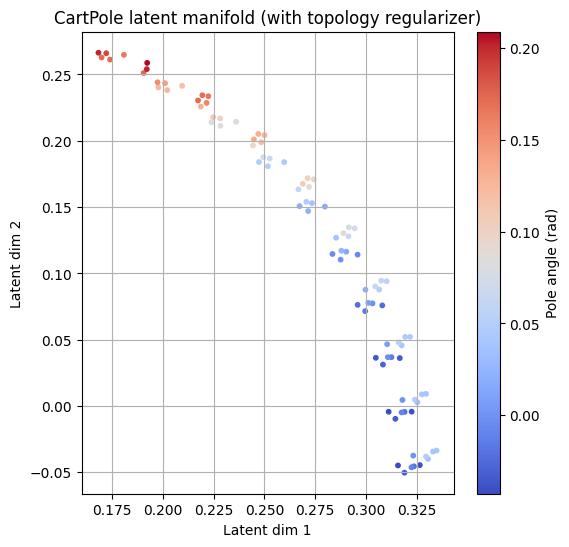

In [ ]:
# ============================================
# Cell 4: Visualize CartPole latent manifold
# ============================================

def collect_latents_cartpole(net, n_episodes=10):
    env = gym.make("CartPole-v1")
    latents = []
    angles = []
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_ret = 0.0
        while not done:
            obs_t = torch.from_numpy(obs).float().unsqueeze(0).to(device)
            with torch.no_grad():
                z, logits, _ = net(obs_t)
            z_np = z.squeeze(0).cpu().numpy()
            latents.append(z_np)
            angles.append(obs[2])  # pole angle

            probs = torch.softmax(logits, dim=-1)
            action = torch.argmax(probs, dim=-1).item()
            obs, r, terminated, truncated, _ = env.step(action)
            ep_ret += r
            done = terminated or truncated
        returns.append(ep_ret)
    env.close()
    return np.array(latents), np.array(angles), returns

latents, angles, returns_vis = collect_latents_cartpole(net_topo, n_episodes=10)
print("Collected latent points:", latents.shape)
print("Example episode returns:", returns_vis)

plt.figure(figsize=(6,6))
sc = plt.scatter(latents[:,0], latents[:,1],
                 c=angles, cmap="coolwarm", s=10)
plt.colorbar(sc, label="Pole angle (rad)")
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("CartPole latent manifold (with topology regularizer)")
plt.grid(True)
plt.show()

CNN MNIST

In [ ]:
# ============================================
# Cell 5: CNN + topology-inspired loss on MNIST
# ============================================

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

train_ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256, shuffle=False)

class SmallCNN(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_latent = nn.Linear(32 * 7 * 7, latent_dim)
        self.fc_out = nn.Linear(latent_dim, 10)

    def forward(self, x):
        h = self.conv(x)               # [B, 32, 7, 7]
        h_flat = h.view(h.size(0), -1)
        z = torch.tanh(self.fc_latent(h_flat))  # [B, latent_dim]
        logits = self.fc_out(z)
        return z, logits

cnn = SmallCNN(latent_dim=32).to(device)
opt_cnn = optim.Adam(cnn.parameters(), lr=1e-3)

def evaluate_mnist(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            _, logits = model(x)
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

epochs = 3
topology_weight = 1e-3

for epoch in range(1, epochs+1):
    cnn.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        z, logits = cnn(x)
        ce_loss = F.cross_entropy(logits, y)

        # Subsample if batch too big for pairwise
        if z.size(0) > 64:
            idx = torch.randperm(z.size(0))[:64]
            x_sub = x[idx].view(64, -1)
            z_sub = z[idx]
        else:
            x_sub = x.view(x.size(0), -1)
            z_sub = z

        topo_loss = topology_surrogate_loss(x_sub.detach(), z_sub)
        loss = ce_loss + topology_weight * topo_loss

        opt_cnn.zero_grad()
        loss.backward()
        opt_cnn.step()

        total_loss += loss.item() * x.size(0)

    avg_loss = total_loss / len(train_ds)
    acc = evaluate_mnist(cnn)
    print(f"Epoch {epoch} | Loss {avg_loss:.4f} | Test Acc {acc*100:.2f}%")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 545kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.43MB/s]


Epoch 1 | Loss 0.3149 | Test Acc 97.98%
Epoch 2 | Loss 0.0698 | Test Acc 98.30%
Epoch 3 | Loss 0.0463 | Test Acc 98.71%


Embeddings

Embeddings shape for 0: (300, 32)
Embeddings shape for 1: (300, 32)


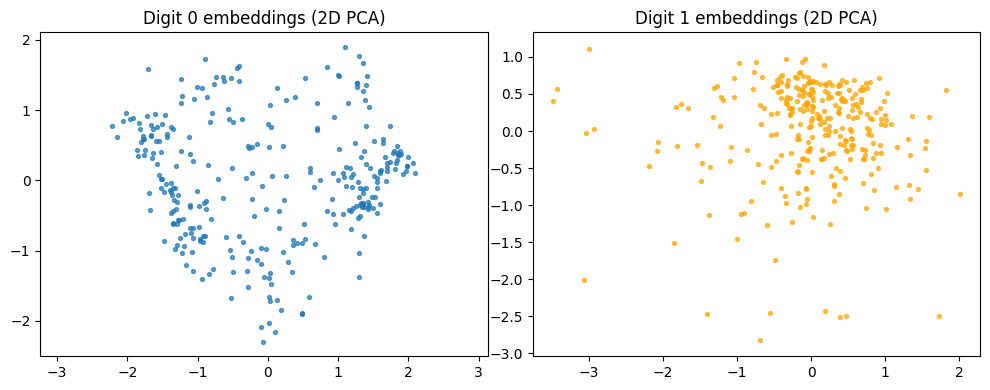

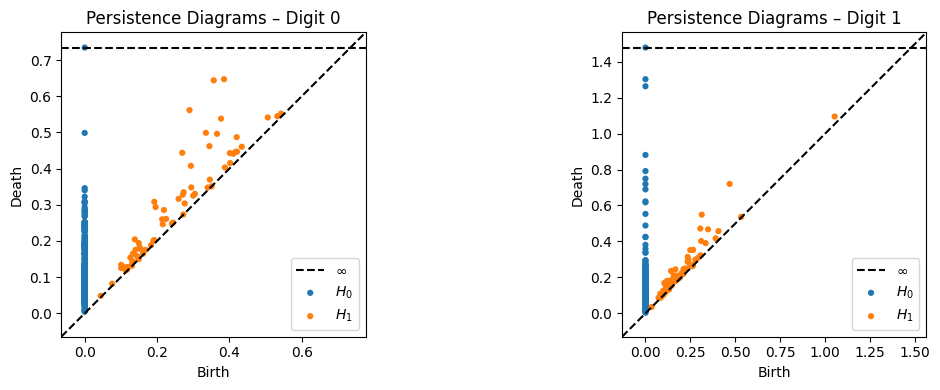

In [ ]:
# ============================================
# Cell 6: Embeddings → PD → visualization
# ============================================

# Collect embeddings for digit '0' and '1' from test set
cnn.eval()
emb_0 = []
emb_1 = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        z, _ = cnn(x)
        z_np = z.cpu().numpy()
        y_np = y.cpu().numpy()
        emb_0.append(z_np[y_np == 0])
        emb_1.append(z_np[y_np == 1])
        if sum(len(e) for e in emb_0) > 300 and sum(len(e) for e in emb_1) > 300:
            break

emb_0 = np.vstack(emb_0)[:300]    # [N0, d]
emb_1 = np.vstack(emb_1)[:300]    # [N1, d]

print("Embeddings shape for 0:", emb_0.shape)
print("Embeddings shape for 1:", emb_1.shape)

# Dim reduce to 2D for PD on point clouds (optional but helpful)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_0_2d = pca.fit_transform(emb_0)
emb_1_2d = pca.fit_transform(emb_1)

# Compute PDs with ripser
dgms_0 = ripser(emb_0_2d)['dgms']
dgms_1 = ripser(emb_1_2d)['dgms']

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(emb_0_2d[:,0], emb_0_2d[:,1], s=8, alpha=0.7)
plt.title("Digit 0 embeddings (2D PCA)")
plt.axis("equal")

plt.subplot(1,2,2)
plt.scatter(emb_1_2d[:,0], emb_1_2d[:,1], s=8, alpha=0.7, color='orange')
plt.title("Digit 1 embeddings (2D PCA)")
plt.axis("equal")

plt.tight_layout()
plt.show()

# Plot persistence diagrams (0D and 1D)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_diagrams(dgms_0, show=False)
plt.title("Persistence Diagrams – Digit 0")

plt.subplot(1,2,2)
plot_diagrams(dgms_1, show=False)
plt.title("Persistence Diagrams – Digit 1")

plt.tight_layout()
plt.show()

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.metrics import pairwise_distances

# 1D toy dataset projected in 2D for view
points = np.array([
    [0.1, 0.2],
    [0.35, 0.22],
    [0.38, 0.24],
    [0.72, 0.2],
    [0.78, 0.22]
])

dist = pairwise_distances(points)

eps_values = np.linspace(0, 0.7, 30)

fig, ax = plt.subplots(figsize=(6,4))
sc = ax.scatter(points[:,0], points[:,1], s=100)
ax.set_xlim(0,1)
ax.set_ylim(0,0.6)

title = ax.text(0.02, 0.95, '', transform=ax.transAxes)

lines = []

def update(frame):
    global lines
    eps = eps_values[frame]

    # clear previous edges
    for ln in lines:
        ln.remove()
    lines.clear()

    # Build graph connectivity
    n = len(points)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a,b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    # Draw edges where dist < eps
    for i in range(n):
        for j in range(i+1,n):
            if dist[i,j] <= eps:
                ln, = ax.plot(
                    [points[i,0], points[j,0]],
                    [points[i,1], points[j,1]],
                    'b-', linewidth=2
                )
                lines.append(ln)
                union(i,j)

    # Count components
    comps = len(set(find(i) for i in range(n)))

    title.set_text(f"ε = {eps:.2f}   H₀ components = {comps}")

ani = FuncAnimation(fig, update, frames=len(eps_values), interval=300)
plt.close()



In [ ]:
from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
from ripser import ripser
from persim import plot_diagrams
from matplotlib.animation import FuncAnimation

dgms = ripser(points)['dgms']

fig, ax = plt.subplots(figsize=(6,4))
ax.set_xlim(0, 0.7)
ax.set_ylim(-0.5, len(points)+1)
ax.set_xlabel("ε")
ax.set_title("H0 Barcode Evolution")

bars = []

def draw_bar(birth, death, idx):
    return ax.plot([birth, death], [idx, idx], 'r-', lw=3)[0]

def animate_bar(frame):
    eps = eps_values[frame]
    ax.clear()
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.5, len(points)+1)
    ax.set_xlabel("ε")
    ax.set_title(f"H0 Barcode   ε={eps:.2f}")

    i = 0
    for (birth, death) in dgms[0]:
        d = min(death, eps)
        if eps >= birth:
            ax.plot([birth, d], [i,i], 'r-', lw=3)
        i += 1

ani2 = FuncAnimation(fig, animate_bar, frames=len(eps_values), interval=300)
plt.close()

HTML(ani2.to_jshtml())

The barcode animation for clusters and holes are different.

H0: Short bars none lasting long

H1: long bar lasting long time indicates cycle or loop

       |-----------|
          |-----|


In [ ]:
# ============================================
# H1 animation: loop forming and dying
# ============================================

!pip install -q ripser persim

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.metrics import pairwise_distances
from ripser import ripser

# 1) Generate points on a noisy circle
np.random.seed(0)
n_points = 30
theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
r = 1.0 + 0.05 * np.random.randn(n_points)  # small radial noise
X = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)  # [N,2]

# 2) Compute pairwise distances
D = pairwise_distances(X)

# 3) Compute persistent homology with ripser
res = ripser(X)
dgms = res['dgms']
dgm_H1 = dgms[1]

print("H1 diagram:", dgm_H1)

# Grab the most persistent H1 feature (the main loop)
if len(dgm_H1) > 0:
    pers = dgm_H1[:,1] - dgm_H1[:,0]
    idx_main = np.argmax(pers)
    birth_main, death_main = dgm_H1[idx_main]
else:
    birth_main, death_main = None, None

print(f"Main H1 loop: birth={birth_main:.3f}, death={death_main:.3f}")

# 4) Epsilon values we will sweep through
eps_values = np.linspace(0.0, death_main*1.2, 40)  # go a bit beyond death

# 5) Union-Find helper for counting components (H0), optional but nice
def count_components(eps):
    n = len(X)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a,b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    for i in range(n):
        for j in range(i+1, n):
            if D[i,j] <= eps:
                union(i,j)

    comps = len(set(find(i) for i in range(n)))
    return comps

# 6) Set up the figure for animation
fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal', 'box')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)

sc = ax.scatter(X[:,0], X[:,1], s=40, color='black')
title = ax.text(0.02, 0.97, '', transform=ax.transAxes, va='top')

lines = []

def update(frame):
    global lines
    eps = eps_values[frame]

    # Remove old edges
    for ln in lines:
        ln.remove()
    lines.clear()

    # Draw edges for pairs with D <= eps
    n = len(X)
    for i in range(n):
        for j in range(i+1, n):
            if D[i,j] <= eps:
                ln, = ax.plot([X[i,0], X[j,0]],
                              [X[i,1], X[j,1]],
                              'tab:blue', lw=1.5, alpha=0.8)
                lines.append(ln)

    # Compute H0 components (optional but informative)
    comps = count_components(eps)

    # Determine if main H1 loop is "alive" at this eps
    if birth_main is not None and death_main is not None:
        loop_alive = (eps >= birth_main) and (eps <= death_main)
    else:
        loop_alive = False

    loop_status = "ALIVE" if loop_alive else "not yet / already dead"

    title.set_text(
        f"ε = {eps:.3f}\n"
        f"H0 components = {comps}\n"
        f"Main H1 loop: {loop_status}\n"
        f"(birth={birth_main:.3f}, death={death_main:.3f})"
    )

ani = FuncAnimation(fig, update, frames=len(eps_values), interval=300)
plt.close()

from IPython.display import HTML
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gudhi as gd
import gudhi.representations as gdr
from sklearn.preprocessing import StandardScaler
from collections import deque
import random

# --- 1. Topological Utilities ---
def get_h1_landscape(trajectory, num_layers=5, res=100):
    """Computes the H1 Persistence Landscape for a trajectory."""
    if len(trajectory) < 10:
        return np.zeros(num_layers * res)

    # Normalize and build Rips Complex
    pts = StandardScaler().fit_transform(trajectory)
    rips = gd.RipsComplex(points=pts, max_edge_length=1.0)
    stree = rips.create_simplex_tree(max_dimension=2)
    diag = stree.persistence()

    # Extract H1 pairs (birth, death)
    h1_points = [p[1] for p in diag if p[0] == 1]

    if not h1_points:
        return np.zeros(num_layers * res)

    # Generate Landscape
    ls = gdr.Landscape(num_landscapes=num_layers, resolution=res)
    return ls.fit_transform([np.array(h1_points)]).flatten()

# --- 2. Topological Replay Buffer ---
class TopologyBuffer:
    def __init__(self, capacity=1000):
        self.capacity = capacity
        self.buffer = []
        self.expert_ls = None # The 'Gold Standard' manifold

    def add(self, trajectory, reward, landscape):
        # Expert Promotion: Highest reward with stable topology becomes the reference
        if self.expert_ls is None or reward > self.best_reward:
            self.expert_ls = landscape
            self.best_reward = reward

        self.buffer.append({'traj': trajectory, 'reward': reward, 'ls': landscape})
        if len(self.buffer) > self.capacity:
            self.buffer.pop(0)

    def sample(self, batch_size):
        if not self.buffer: return []
        # Priority = 1 / (L2 distance to Expert Landscape + epsilon)
        distances = [np.linalg.norm(e['ls'] - self.expert_ls) for e in self.buffer]
        priorities = 1.0 / (np.array(distances) + 1e-6)
        probs = priorities / priorities.sum()

        return random.choices(self.buffer, weights=probs, k=batch_size)

# --- 3. Neural Network Agent ---
class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

# --- 4. Main Training Loop ---
env = gym.make("CartPole-v1")
agent = Agent()
optimizer = optim.Adam(agent.parameters(), lr=1e-3)
topo_buffer = TopologyBuffer()



for episode in range(100):
    obs, _ = env.reset()
    trajectory, episode_reward = [], 0
    done = False

    while not done:
        # Act
        state_t = torch.tensor(obs, dtype=torch.float32)
        logits = agent(state_t)
        action = torch.argmax(logits).item()

        # Step
        next_obs, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(obs)
        episode_reward += reward
        obs = next_obs
        done = terminated or truncated

    # End of Episode: Compute Topology
    current_ls = get_h1_landscape(np.array(trajectory))
    topo_buffer.add(trajectory, episode_reward, current_ls)

    # Training Step with Topological Prioritization
    if len(topo_buffer.buffer) > 10:
        batch = topo_buffer.sample(5)
        for data in batch:
            # Standard RL update (e.g., REINFORCE or simple supervised on successful shapes)
            # This 'pulls' the agent toward trajectories with low L2 distance to the expert
            pass

    print(f"Episode {episode} | Reward: {episode_reward} | Expert Reward: {topo_buffer.best_reward}")

env.close()

Episode 0 | Reward: 9.0 | Expert Reward: 9.0
Episode 1 | Reward: 10.0 | Expert Reward: 10.0
Episode 2 | Reward: 9.0 | Expert Reward: 10.0
Episode 3 | Reward: 10.0 | Expert Reward: 10.0
Episode 4 | Reward: 10.0 | Expert Reward: 10.0
Episode 5 | Reward: 8.0 | Expert Reward: 10.0
Episode 6 | Reward: 8.0 | Expert Reward: 10.0
Episode 7 | Reward: 10.0 | Expert Reward: 10.0
Episode 8 | Reward: 10.0 | Expert Reward: 10.0
Episode 9 | Reward: 10.0 | Expert Reward: 10.0
Episode 10 | Reward: 10.0 | Expert Reward: 10.0
Episode 11 | Reward: 9.0 | Expert Reward: 10.0
Episode 12 | Reward: 9.0 | Expert Reward: 10.0
Episode 13 | Reward: 9.0 | Expert Reward: 10.0
Episode 14 | Reward: 9.0 | Expert Reward: 10.0
Episode 15 | Reward: 9.0 | Expert Reward: 10.0
Episode 16 | Reward: 10.0 | Expert Reward: 10.0
Episode 17 | Reward: 10.0 | Expert Reward: 10.0
Episode 18 | Reward: 8.0 | Expert Reward: 10.0
Episode 19 | Reward: 9.0 | Expert Reward: 10.0
Episode 20 | Reward: 10.0 | Expert Reward: 10.0
Episode 21 | R

In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 42.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Running simulation...
Generating Interactive Animation...


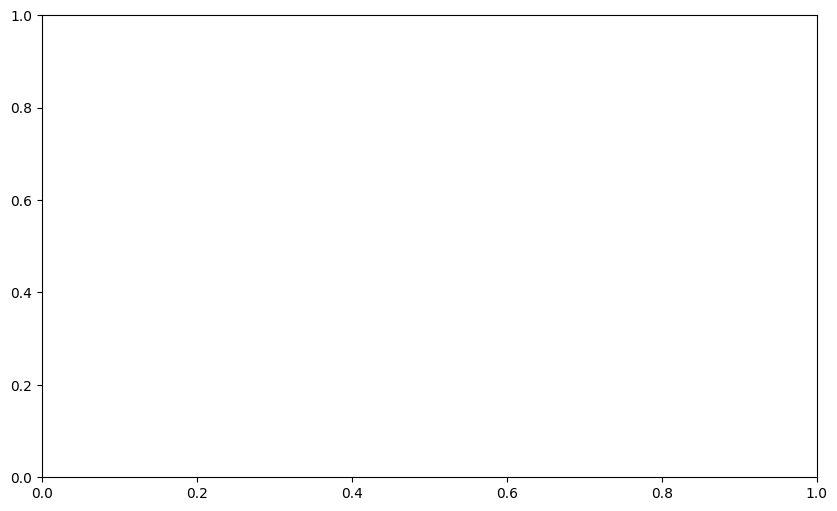

Exporting Video File...


/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import gudhi as gd
from sklearn.preprocessing import StandardScaler
from gymnasium.wrappers import RecordVideo

# --- 1. Topological Animation Logic ---

def animate_persistence(trajectory):
    """Generates an interactive animation of the barcode growth."""
    pts = StandardScaler().fit_transform(trajectory)
    rips = gd.RipsComplex(points=pts, max_edge_length=2.0)
    stree = rips.create_simplex_tree(max_dimension=2)
    diag = stree.persistence()

    h0_bars = [p[1] for p in diag if p[0] == 0]
    h1_bars = [p[1] for p in diag if p[0] == 1]

    fig, ax = plt.subplots(figsize=(10, 6))
    eps_values = np.linspace(0, 1.5, 100)
    offset = len(h0_bars) + 2

    def update(epsilon):
        ax.clear()
        for i, (birth, death) in enumerate(h0_bars):
            if birth <= epsilon:
                ax.hlines(y=i, xmin=birth, xmax=min(death, epsilon), color='red', linewidth=2)
        for i, (birth, death) in enumerate(h1_bars):
            if birth <= epsilon:
                ax.hlines(y=i + offset, xmin=birth, xmax=min(death, epsilon), color='blue', linewidth=3)

        ax.set_title(f"Persistence Barcode Filtration (ε = {epsilon:.3f})")
        ax.set_xlim(0, 1.5)
        ax.set_ylim(-1, offset + len(h1_bars) + 1)

    ani = FuncAnimation(fig, update, frames=eps_values, interval=50)
    plt.show()

def export_topo_animation(trajectory, filename="/content/topo_evolution.mp4"):
    """Saves the barcode evolution as a high-quality MP4 file."""
    pts = StandardScaler().fit_transform(trajectory)
    rips = gd.RipsComplex(points=pts, max_edge_length=2.0)
    stree = rips.create_simplex_tree(max_dimension=2)
    diag = stree.persistence()

    h0_bars = [p[1] for p in diag if p[0] == 0]
    h1_bars = [p[1] for p in diag if p[0] == 1]

    fig, ax = plt.subplots(figsize=(12, 7))
    writer = FFMpegWriter(fps=20, bitrate=1800)
    offset = len(h0_bars) + 2
    eps_values = np.linspace(0, 1.5, 120)

    with writer.saving(fig, filename, dpi=100):
        for epsilon in eps_values:
            ax.clear()
            # Plot H0 (Connectivity)
            for i, (birth, death) in enumerate(h0_bars):
                if birth <= epsilon:
                    ax.hlines(y=i, xmin=birth, xmax=min(death, epsilon), color='salmon', linewidth=3)
            # Plot H1 (Loops/Cycles)
            for i, (birth, death) in enumerate(h1_bars):
                if birth <= epsilon:
                    ax.hlines(y=i + offset, xmin=birth, xmax=min(death, epsilon), color='royalblue', linewidth=4)

            ax.set_title(f"Topology Evolution | ε = {epsilon:.3f}")
            ax.set_xlim(0, 1.5)
            ax.set_ylim(-1, offset + len(h1_bars) + 1)
            writer.grab_frame()
    plt.close()

# --- 2. Simulation and Data Collection ---

env = gym.make("CartPole-v1", render_mode="rgb_array")
# Optional: Record the physical video to sync with topology later
env = RecordVideo(env, video_folder="eval_videos", name_prefix="topo_run")

obs, _ = env.reset()
trajectory = []
done = False

print("Running simulation...")
while not done:
    action = env.action_space.sample() # Random policy for initial manifold exploration
    obs, reward, terminated, truncated, _ = env.step(action)
    trajectory.append(obs)
    done = terminated or truncated

env.close()
trajectory_np = np.array(trajectory)

# --- 3. Run Topological Visualizations ---

print("Generating Interactive Animation...")
animate_persistence(trajectory_np)

print("Exporting Video File...")
export_topo_animation(trajectory_np, filename="/content/cartpole_topo_signature.mp4")

# **Working CartPole example with topology surrogate**

In [ ]:
!pip install -q gymnasium[classic-control] ripser persim

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
def pairwise_distances(x: torch.Tensor) -> torch.Tensor:
    diff = x.unsqueeze(1) - x.unsqueeze(0)   # [N, N, D]
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)
    return dist

def topology_surrogate_loss(x_in: torch.Tensor,
                            z_latent: torch.Tensor) -> torch.Tensor:
    """
    x_in: [N, d_in]      (no grad)
    z_latent: [N, d_latent]  (grad)
    Encourages the latent distance structure to resemble input distance structure.
    """
    with torch.no_grad():
        D_in = pairwise_distances(x_in)
        D_in = D_in / (D_in.max() + 1e-8)

    D_lat = pairwise_distances(z_latent)
    D_lat = D_lat / (D_lat.max() + 1e-8)

    return F.mse_loss(D_lat, D_in)

In [ ]:
class CartPoleActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.value_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs: torch.Tensor):
        z = self.encoder(obs)
        logits = self.policy_head(z)
        value = self.value_head(z).squeeze(-1)
        return z, logits, value

    def act(self, obs_np):
        obs_t = torch.from_numpy(obs_np).float().unsqueeze(0).to(device)
        z, logits, value = self.forward(obs_t)
        probs = torch.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob, value.item()

[λ=0e+00] Ep  20 | Return   16.0 | Avg20  15.40 | TopoLoss 0.0000
[λ=0e+00] Ep  40 | Return   20.0 | Avg20  15.40 | TopoLoss 0.0000
[λ=0e+00] Ep  60 | Return   15.0 | Avg20  14.85 | TopoLoss 0.0000
[λ=0e+00] Ep  80 | Return   17.0 | Avg20  14.60 | TopoLoss 0.0000
[λ=0e+00] Ep 100 | Return   14.0 | Avg20  15.05 | TopoLoss 0.0000
[λ=0e+00] Ep 120 | Return   12.0 | Avg20  13.50 | TopoLoss 0.0000
[λ=0e+00] Ep 140 | Return    8.0 | Avg20  14.60 | TopoLoss 0.0000
[λ=0e+00] Ep 160 | Return   16.0 | Avg20  15.95 | TopoLoss 0.0000
[λ=0e+00] Ep 180 | Return   13.0 | Avg20  15.85 | TopoLoss 0.0000
[λ=0e+00] Ep 200 | Return    9.0 | Avg20  17.85 | TopoLoss 0.0000
[λ=1e-02] Ep  20 | Return   13.0 | Avg20  18.50 | TopoLoss 0.0010
[λ=1e-02] Ep  40 | Return   10.0 | Avg20  14.40 | TopoLoss 0.0009
[λ=1e-02] Ep  60 | Return   12.0 | Avg20  18.60 | TopoLoss 0.0026
[λ=1e-02] Ep  80 | Return   11.0 | Avg20  20.20 | TopoLoss 0.0046
[λ=1e-02] Ep 100 | Return   14.0 | Avg20  20.60 | TopoLoss 0.0059
[λ=1e-02] 

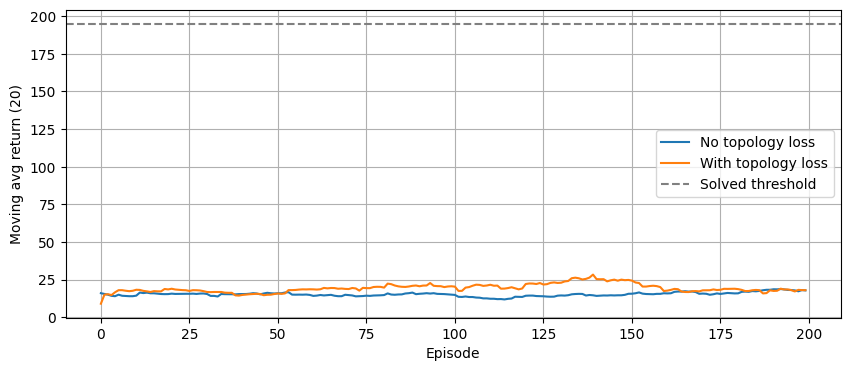

In [ ]:
def train_cartpole(topology_weight=0.0,
                   n_episodes=200,
                   gamma=0.99,
                   print_every=20):
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    net = CartPoleActorCritic(obs_dim, n_actions).to(device)
    optimizer = optim.Adam(net.parameters(), lr=1e-3)

    ep_returns = []
    moving_avg = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        done = False

        log_probs = []
        values = []
        rewards = []
        states = []

        while not done:
            action, log_prob, value = net.act(obs)
            next_obs, r, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(torch.tensor(value, dtype=torch.float32, device=device))
            rewards.append(r)
            states.append(obs)

            obs = next_obs

        # Compute returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32, device=device)

        values_t = torch.stack(values)
        advantages = returns - values_t.detach()

        log_probs_t = torch.stack(log_probs)
        policy_loss = -(log_probs_t * advantages).mean()
        value_loss = F.mse_loss(values_t, returns)

        # Topology surrogate over episode states
        states_t = torch.tensor(states, dtype=torch.float32, device=device)
        z_latent, _, _ = net(states_t)
        topo_loss = torch.tensor(0.0, device=device)
        if topology_weight > 0.0:
            topo_loss = topology_surrogate_loss(
                states_t.detach().view(states_t.size(0), -1),
                z_latent
            )

        loss = policy_loss + 0.5 * value_loss + topology_weight * topo_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ep_ret = sum(rewards)
        ep_returns.append(ep_ret)
        avg20 = np.mean(ep_returns[-20:])
        moving_avg.append(avg20)

        if ep % print_every == 0:
            print(f"[λ={topology_weight:.0e}] Ep {ep:3d} | "
                  f"Return {ep_ret:6.1f} | Avg20 {avg20:6.2f} | "
                  f"TopoLoss {topo_loss.item():.4f}")

    env.close()
    return net, ep_returns, moving_avg

# Train baseline and topo agents
net_no_topo, ret_no, ma_no = train_cartpole(topology_weight=0.0, n_episodes=200)
net_topo,    ret_top, ma_top = train_cartpole(topology_weight=1e-2, n_episodes=200)

plt.figure(figsize=(10,4))
plt.plot(ma_no,  label="No topology loss")
plt.plot(ma_top, label="With topology loss")
plt.axhline(195, color="gray", linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Moving avg return (20)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def collect_latents(net, n_episodes=10, max_steps=500):
    env = gym.make("CartPole-v1")
    latents = []
    angles  = []   # pole angle (obs[2])
    net.eval()
    with torch.no_grad():
        for _ in range(n_episodes):
            obs, _ = env.reset()
            done = False
            steps = 0
            while not done and steps < max_steps:
                obs_t = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                z, logits, _ = net(obs_t)
                probs = torch.softmax(logits, dim=-1)
                action = probs.argmax(dim=-1).item()

                latents.append(z.squeeze(0).cpu().numpy())
                angles.append(obs[2])

                obs, r, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                steps += 1
    env.close()
    return np.array(latents), np.array(angles)

lat_no,  ang_no  = collect_latents(net_no_topo, n_episodes=10)
lat_top, ang_top = collect_latents(net_topo,    n_episodes=10)

print("No-topo latents:", lat_no.shape)
print("Topo    latents:", lat_top.shape)

No-topo latents: (96, 2)
Topo    latents: (94, 2)


In [ ]:
from sklearn.metrics import pairwise_distances
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_H0_H1(latents, title_prefix="Topo agent"):
    X = latents   # [N, 2] (latent dim 2)

    # pairwise distances
    D = pairwise_distances(X)

    # persistent homology
    res = ripser(X)
    dgms = res['dgms']
    dgm_H1 = dgms[1]
    print(title_prefix, "H1 diagram (first few):", dgm_H1[:5])

    # find main H1 loop (if any)
    if len(dgm_H1) > 0:
        pers = dgm_H1[:,1] - dgm_H1[:,0]
        idx_main = np.argmax(pers)
        birth_main, death_main = dgm_H1[idx_main]
    else:
        birth_main, death_main = None, None

    print(f"{title_prefix} main H1 loop: birth={birth_main}, death={death_main}")

    # epsilon sweep
    if birth_main is not None and death_main is not None:
        eps_min = max(0.0, birth_main * 0.3)
        eps_max = death_main * 1.3
    else:
        eps_min, eps_max = 0.0, D.max()
    eps_values = np.linspace(eps_min, eps_max, 40)

    # helper to count H0 components
    def count_components(eps):
        n = len(X)
        parent = list(range(n))
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x
        def union(a,b):
            pa, pb = find(a), find(b)
            if pa != pb:
                parent[pb] = pa
        for i in range(n):
            for j in range(i+1, n):
                if D[i,j] <= eps:
                    union(i,j)
        return len(set(find(i) for i in range(n)))

    # setup figure
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_aspect("equal", "box")
    ax.set_xlim(X[:,0].min()-0.2, X[:,0].max()+0.2)
    ax.set_ylim(X[:,1].min()-0.2, X[:,1].max()+0.2)

    sc = ax.scatter(X[:,0], X[:,1], s=20, color="black", alpha=0.7)
    title = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top")
    lines = []

    def update(frame):
        nonlocal lines
        eps = eps_values[frame]

        # drop old edges
        for ln in lines:
            ln.remove()
        lines.clear()

        # draw edges
        n = len(X)
        for i in range(n):
            for j in range(i+1, n):
                if D[i,j] <= eps:
                    ln, = ax.plot([X[i,0], X[j,0]],
                                  [X[i,1], X[j,1]],
                                  "tab:blue", lw=1.0, alpha=0.6)
                    lines.append(ln)

        # H0 components
        comps = count_components(eps)

        # H1 main loop alive?
        if birth_main is not None and death_main is not None:
            loop_alive = (eps >= birth_main) and (eps <= death_main)
        else:
            loop_alive = False

        status = "ALIVE" if loop_alive else "not yet / already filled"

        title.set_text(
            f"{title_prefix}\n"
            f"ε = {eps:.3f}\n"
            f"H₀ components = {comps}\n"
            f"Main H₁ loop: {status}"
        )

    ani = FuncAnimation(fig, update, frames=len(eps_values), interval=300)
    plt.close()
    return HTML(ani.to_jshtml())

# Animate topo agent
animate_H0_H1(lat_top, title_prefix="Topo agent latent manifold")

Topo agent latent manifold H1 diagram (first few): [[0.02462029 0.02523363]
 [0.01981892 0.02479877]
 [0.01649798 0.01917459]
 [0.0124546  0.01280212]
 [0.01035658 0.01123824]]
Topo agent latent manifold main H1 loop: birth=0.019818924367427826, death=0.024798767641186714


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

class CartPoleActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.value_head = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs: torch.Tensor):
        z = self.encoder(obs)
        logits = self.policy_head(z)
        value = self.value_head(z).squeeze(-1)
        return z, logits, value

    def act(self, obs_np):
        obs_t = torch.from_numpy(obs_np).float().unsqueeze(0).to(device)
        z, logits, value = self.forward(obs_t)
        probs = torch.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob, value.item()

def pairwise_distances(x: torch.Tensor) -> torch.Tensor:
    diff = x.unsqueeze(1) - x.unsqueeze(0)   # [N, N, D]
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)
    return dist

def topology_surrogate_loss(x_in: torch.Tensor,
                            z_latent: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        D_in = pairwise_distances(x_in)
        D_in = D_in / (D_in.max() + 1e-8)

    D_lat = pairwise_distances(z_latent)
    D_lat = D_lat / (D_lat.max() + 1e-8)

    return F.mse_loss(D_lat, D_in)

Using device: cpu


In [ ]:
def collect_latents(net, n_episodes=5, max_steps=500, max_points=600):
    env = gym.make("CartPole-v1")
    latents = []
    net.eval()
    with torch.no_grad():
        for _ in range(n_episodes):
            obs, _ = env.reset()
            done = False
            steps = 0
            while not done and steps < max_steps:
                obs_t = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                z, logits, _ = net(obs_t)
                probs = torch.softmax(logits, dim=-1)
                action = probs.argmax(dim=-1).item()

                latents.append(z.squeeze(0).cpu().numpy())
                obs, r, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                steps += 1
    env.close()
    latents = np.asarray(latents)

    # Subsample to keep PH fast
    if latents.shape[0] > max_points:
        idx = np.random.choice(latents.shape[0], size=max_points, replace=False)
        latents = latents[idx]
    return latents

def compute_pd(latents):
    """Return (H0, H1) diagrams for a 2D latent cloud."""
    dgms = ripser(latents)['dgms']
    dgm_H0 = dgms[0]
    dgm_H1 = dgms[1] if len(dgms) > 1 else np.zeros((0, 2))
    return dgm_H0, dgm_H1

def safe_wasserstein(dgm1, dgm2):
    """Handle empty diagrams gracefully."""
    if len(dgm1) == 0 and len(dgm2) == 0:
        return 0.0
    return float(wasserstein(dgm1, dgm2, matching=False))

In [ ]:
def train_cartpole_dual_with_topology_tracking(
    n_episodes=200,
    gamma=0.99,
    topo_weight=1e-2,
    checkpoint_every=40
):
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    # Two agents
    net_no = CartPoleActorCritic(obs_dim, n_actions).to(device)
    net_top = CartPoleActorCritic(obs_dim, n_actions).to(device)

    opt_no = optim.Adam(net_no.parameters(), lr=1e-3)
    opt_top = optim.Adam(net_top.parameters(), lr=1e-3)

    ep_returns_no, mv_no = [], []
    ep_returns_top, mv_top = [], []

    # PD logs (per checkpoint)
    ckpts = []
    pd_no_H0, pd_no_H1 = [], []
    pd_top_H0, pd_top_H1 = [], []

    def run_episode(net, opt, use_topology=False):
        obs, _ = env.reset()
        done = False

        log_probs = []
        values = []
        rewards = []
        states = []

        while not done:
            action, log_prob, value = net.act(obs)
            next_obs, r, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(torch.tensor(value, dtype=torch.float32, device=device))
            rewards.append(r)
            states.append(obs)

            obs = next_obs

        # returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32, device=device)

        values_t = torch.stack(values)
        advantages = returns - values_t.detach()
        log_probs_t = torch.stack(log_probs)

        policy_loss = -(log_probs_t * advantages).mean()
        value_loss = F.mse_loss(values_t, returns)

        states_t = torch.tensor(states, dtype=torch.float32, device=device)
        z_latent, _, _ = net(states_t)

        topo_loss = torch.tensor(0.0, device=device)
        if use_topology and topo_weight > 0.0:
            topo_loss = topology_surrogate_loss(
                states_t.detach().view(states_t.size(0), -1),
                z_latent
            )

        loss = policy_loss + 0.5 * value_loss + topo_weight * topo_loss * (1.0 if use_topology else 0.0)

        opt.zero_grad()
        loss.backward()
        opt.step()

        return sum(rewards), topo_loss.item()

    # Initial PD at episode 0 (random policies)
    lat_no_0  = collect_latents(net_no,  n_episodes=3)
    lat_top_0 = collect_latents(net_top, n_episodes=3)
    H0_no_0, H1_no_0   = compute_pd(lat_no_0)
    H0_top_0, H1_top_0 = compute_pd(lat_top_0)

    ckpts.append(0)
    pd_no_H0.append(H0_no_0)
    pd_no_H1.append(H1_no_0)
    pd_top_H0.append(H0_top_0)
    pd_top_H1.append(H1_top_0)

    # Training loop
    for ep in range(1, n_episodes + 1):
        # no-topology agent
        ret_n, _ = run_episode(net_no, opt_no, use_topology=False)
        ep_returns_no.append(ret_n)
        mv_no.append(np.mean(ep_returns_no[-20:]))

        # topology agent
        ret_t, topo_loss_val = run_episode(net_top, opt_top, use_topology=True)
        ep_returns_top.append(ret_t)
        mv_top.append(np.mean(ep_returns_top[-20:]))

        if ep % 20 == 0:
            print(f"Ep {ep:3d} | No-topo avg20={mv_no[-1]:6.2f} | "
                  f"Topo avg20={mv_top[-1]:6.2f} | topo_loss={topo_loss_val:.4f}")

        # Checkpoint topology
        if ep % checkpoint_every == 0 or ep == n_episodes:
            lat_no  = collect_latents(net_no,  n_episodes=3)
            lat_top = collect_latents(net_top, n_episodes=3)

            H0_no, H1_no   = compute_pd(lat_no)
            H0_top, H1_top = compute_pd(lat_top)

            ckpts.append(ep)
            pd_no_H0.append(H0_no)
            pd_no_H1.append(H1_no)
            pd_top_H0.append(H0_top)
            pd_top_H1.append(H1_top)

    env.close()

    logs = {
        "episodes":        np.arange(1, n_episodes+1),
        "mv_no":           np.array(mv_no),
        "mv_top":          np.array(mv_top),
        "ckpts":           np.array(ckpts),
        "pd_no_H0":        pd_no_H0,
        "pd_no_H1":        pd_no_H1,
        "pd_top_H0":       pd_top_H0,
        "pd_top_H1":       pd_top_H1,
    }
    return net_no, net_top, logs

net_no, net_top, logs = train_cartpole_dual_with_topology_tracking(
    n_episodes=200,
    checkpoint_every=40
)

Ep  20 | No-topo avg20= 22.70 | Topo avg20= 19.35 | topo_loss=0.0012
Ep  40 | No-topo avg20= 18.45 | Topo avg20= 19.55 | topo_loss=0.0075
Ep  60 | No-topo avg20= 25.25 | Topo avg20= 18.40 | topo_loss=0.0007
Ep  80 | No-topo avg20= 24.60 | Topo avg20= 14.95 | topo_loss=0.0012
Ep 100 | No-topo avg20= 15.05 | Topo avg20= 15.05 | topo_loss=0.0005
Ep 120 | No-topo avg20= 14.05 | Topo avg20= 15.45 | topo_loss=0.0011
Ep 140 | No-topo avg20= 12.65 | Topo avg20= 17.75 | topo_loss=0.0011
Ep 160 | No-topo avg20= 14.65 | Topo avg20= 15.10 | topo_loss=0.0001
Ep 180 | No-topo avg20= 13.20 | Topo avg20= 16.75 | topo_loss=0.0006
Ep 200 | No-topo avg20= 12.00 | Topo avg20= 18.95 | topo_loss=0.0008


In [ ]:
!pip install -q ripser persim


In [ ]:
from persim import wasserstein


ckpts = logs["ckpts"]
pd_no_H0  = logs["pd_no_H0"]
pd_no_H1  = logs["pd_no_H1"]
pd_top_H0 = logs["pd_top_H0"]
pd_top_H1 = logs["pd_top_H1"]

# Distances between models at each checkpoint
dist_between_H0 = []
dist_between_H1 = []

# Self-evolution vs initial
dist_no_self_H0  = []
dist_no_self_H1  = []
dist_top_self_H0 = []
dist_top_self_H1 = []

for k in range(len(ckpts)):
    H0_no = pd_no_H0[k]
    H1_no = pd_no_H1[k]
    H0_top = pd_top_H0[k]
    H1_top = pd_top_H1[k]

    # between models
    dist_between_H0.append(safe_wasserstein(H0_no, H0_top))
    dist_between_H1.append(safe_wasserstein(H1_no, H1_top))

    # vs initial
    dist_no_self_H0.append(safe_wasserstein(pd_no_H0[0],  H0_no))
    dist_no_self_H1.append(safe_wasserstein(pd_no_H1[0],  H1_no))
    dist_top_self_H0.append(safe_wasserstein(pd_top_H0[0], H0_top))
    dist_top_self_H1.append(safe_wasserstein(pd_top_H1[0], H1_top))

dist_between_H0  = np.array(dist_between_H0)
dist_between_H1  = np.array(dist_between_H1)
dist_no_self_H0  = np.array(dist_no_self_H0)
dist_no_self_H1  = np.array(dist_no_self_H1)
dist_top_self_H0 = np.array(dist_top_self_H0)
dist_top_self_H1 = np.array(dist_top_self_H1)

/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.12/di

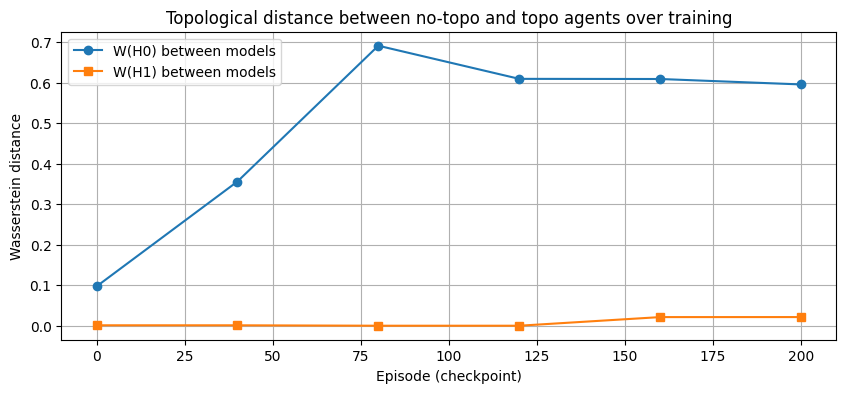

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ckpts, dist_between_H0,  "o-", label="W(H0) between models")
plt.plot(ckpts, dist_between_H1,  "s-", label="W(H1) between models")
plt.xlabel("Episode (checkpoint)")
plt.ylabel("Wasserstein distance")
plt.title("Topological distance between no-topo and topo agents over training")
plt.grid(True)
plt.legend()
plt.show()

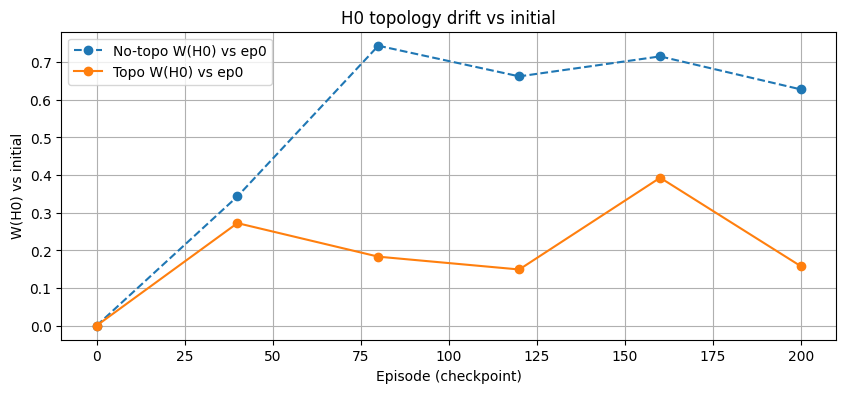

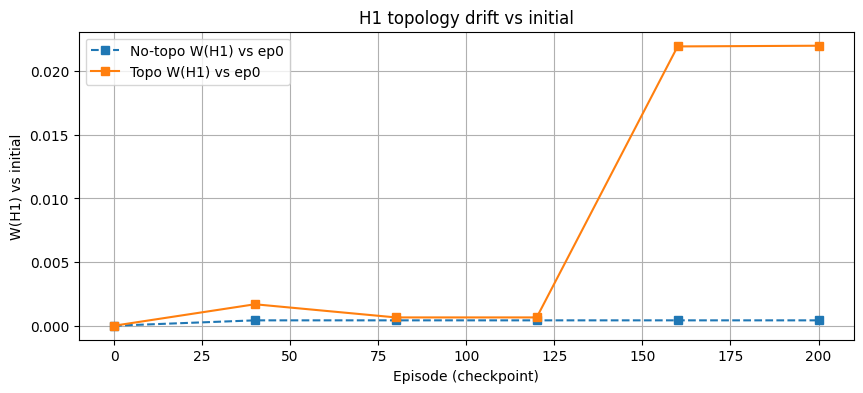

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ckpts, dist_no_self_H0,  "o--", label="No-topo W(H0) vs ep0")
plt.plot(ckpts, dist_top_self_H0, "o-",  label="Topo W(H0) vs ep0")
plt.xlabel("Episode (checkpoint)")
plt.ylabel("W(H0) vs initial")
plt.title("H0 topology drift vs initial")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ckpts, dist_no_self_H1,  "s--", label="No-topo W(H1) vs ep0")
plt.plot(ckpts, dist_top_self_H1, "s-",  label="Topo W(H1) vs ep0")
plt.xlabel("Episode (checkpoint)")
plt.ylabel("W(H1) vs initial")
plt.title("H1 topology drift vs initial")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
!pip install ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.7 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=a521af906bf676bab96b64d25b076121856d9db186ac754797e3492e1995c15e
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


In [ ]:
# Colab cell: in-output animation showing
#  (1) H0 connectivity in geometry (colored connected components + edges)
#  (2) H0 merge curve (#components vs ε)
#  (3) H1 life/death bars with birth/death labels + exact ε annotation
#
# Install (run once): !pip -q install ripser persim scikit-learn scipy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from ripser import ripser

# -----------------------
# Load MNIST-like digits & embed into 2D
# -----------------------
digits = load_digits()
X = digits.data[digits.target == 0]  # "0" usually yields an H1 feature

rng = np.random.default_rng(0)
n = min(180, len(X))  # safe subsample
X = X[rng.choice(len(X), size=n, replace=False)]

X2 = PCA(n_components=2).fit_transform(X)
X2 = (X2 - X2.mean(0)) / (X2.std(0) + 1e-8)

# Pairwise distances + sorted edge list (for incremental VR graph)
D = squareform(pdist(X2))
iu = np.triu_indices(n, k=1)
edge_i = iu[0].astype(int)
edge_j = iu[1].astype(int)
edge_w = D[iu]
order = np.argsort(edge_w)
edge_i, edge_j, edge_w = edge_i[order], edge_j[order], edge_w[order]

# Persistent homology (H0, H1)
ph = ripser(X2, maxdim=1)
dgms = ph["dgms"]

# ε schedule (increasing). Keep it low so the graph doesn't become a hairball.
eps_vals = np.linspace(0.0, np.percentile(edge_w, 12), 55)

# -----------------------
# Union-Find (for H0 connectivity)
# -----------------------
def uf_init(n):
    parent = np.arange(n, dtype=int)
    rank = np.zeros(n, dtype=int)
    return parent, rank

def uf_find(parent, a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

def uf_union(parent, rank, a, b):
    ra, rb = uf_find(parent, a), uf_find(parent, b)
    if ra == rb:
        return False
    if rank[ra] < rank[rb]:
        parent[ra] = rb
    elif rank[ra] > rank[rb]:
        parent[rb] = ra
    else:
        parent[rb] = ra
        rank[ra] += 1
    return True

# Precompute component counts over eps_vals (for the H0 curve)
def compute_component_counts():
    parent, rank = uf_init(n)
    ptr = 0
    comps = n
    counts = []
    for eps in eps_vals:
        while ptr < len(edge_w) and edge_w[ptr] <= eps:
            if uf_union(parent, rank, int(edge_i[ptr]), int(edge_j[ptr])):
                comps -= 1
            ptr += 1
        counts.append(comps)
    return np.array(counts, dtype=int)

comp_counts = compute_component_counts()

# -----------------------
# Prepare H1 life/death bars (top-k by lifetime) + labels
# -----------------------
H1 = dgms[1]
finite = np.isfinite(H1[:, 1])
H1 = H1[finite]

lifetimes = (H1[:, 1] - H1[:, 0])
k = min(12, len(H1))
idx_top = np.argsort(lifetimes)[::-1][:k]
H1_top = H1[idx_top]
# Sort by birth for nicer display
H1_top = H1_top[np.argsort(H1_top[:, 0])]

# Pre-format labels to avoid reformat every frame
births = H1_top[:, 0] if len(H1_top) else np.array([])
deaths = H1_top[:, 1] if len(H1_top) else np.array([])
widths = deaths - births if len(H1_top) else np.array([])
birth_labels = [f"{b:.3f}" for b in births]
death_labels = [f"{d:.3f}" for d in deaths]

# -----------------------
# Figure layout
# -----------------------
fig = plt.figure(figsize=(14, 4))
ax_geom = plt.subplot(1, 3, 1)
ax_h0   = plt.subplot(1, 3, 2)
ax_h1   = plt.subplot(1, 3, 3)

# Animation state: incrementally add edges as eps grows
parent_anim, rank_anim = uf_init(n)
ptr_anim = 0
comps_anim = n
active_edges = []

cmap = plt.cm.tab20

def update(frame):
    global ptr_anim, comps_anim, active_edges, parent_anim, rank_anim

    eps = float(eps_vals[frame])

    # Add edges up to eps (incremental)
    while ptr_anim < len(edge_w) and edge_w[ptr_anim] <= eps:
        a = int(edge_i[ptr_anim]); b = int(edge_j[ptr_anim])
        active_edges.append((a, b))
        if uf_union(parent_anim, rank_anim, a, b):
            comps_anim -= 1
        ptr_anim += 1

    # ---- Left: geometry + H0 connectivity (components as colors) ----
    ax_geom.clear()

    roots = np.array([uf_find(parent_anim, i) for i in range(n)], dtype=int)
    uniq = np.unique(roots)
    comp_id = {r: t for t, r in enumerate(uniq)}
    colors = np.array([cmap(comp_id[r] % 20) for r in roots])

    for (a, b) in active_edges:
        ax_geom.plot([X2[a,0], X2[b,0]], [X2[a,1], X2[b,1]], alpha=0.05, linewidth=1)

    ax_geom.scatter(X2[:,0], X2[:,1], s=18, c=colors, alpha=0.9)
    ax_geom.set_title(f"H0 connectivity (ε={eps:.3f})\ncomponents={comps_anim}")
    ax_geom.axis("off")

    # ---- Middle: H0 merge curve (#components vs ε) + exact eps label ----
    ax_h0.clear()
    ax_h0.plot(eps_vals, comp_counts, linewidth=2)
    ax_h0.axvline(eps, color="red", linestyle="--", linewidth=1.5)
    ax_h0.set_title("H0: #components vs ε")
    ax_h0.set_xlabel("ε")
    ax_h0.set_ylabel("# components")
    ax_h0.set_ylim(0.5, n + 1)

    # annotate exact epsilon
    y_at = comp_counts[frame]
    ax_h0.annotate(
        f"ε={eps:.3f}",
        xy=(eps, y_at),
        xytext=(eps, y_at + max(3, n * 0.05)),
        arrowprops=dict(arrowstyle="->", lw=1),
        ha="center",
        fontsize=10,
    )

    # ---- Right: H1 life/death bar chart + birth/death labels + exact eps ----
    ax_h1.clear()

    if len(H1_top) == 0:
        ax_h1.text(0.5, 0.5, "No H1 features found", ha="center", va="center")
        ax_h1.set_axis_off()
    else:
        y = np.arange(len(H1_top))

        # alive loops at current eps
        alive = (births <= eps) & (eps <= deaths)
        alphas = np.where(alive, 0.9, 0.25)

        # draw bars
        for i in range(len(H1_top)):
            ax_h1.barh(y[i], widths[i], left=births[i], alpha=float(alphas[i]))

        # ε cursor
        ax_h1.axvline(eps, color="red", linestyle="--", linewidth=1.5)

        ax_h1.set_title("H1: loop life/death intervals (top persistent)")
        ax_h1.set_xlabel("ε")
        ax_h1.set_yticks(y)
        ax_h1.set_yticklabels([f"loop {i}" for i in y])

        x_max = max(float(np.max(deaths)), float(eps_vals[-1])) * 1.08
        ax_h1.set_xlim(0.0, x_max)

        # Annotate exact epsilon at top
        ax_h1.text(
            0.02, 0.98,
            f"ε = {eps:.3f}",
            transform=ax_h1.transAxes,
            va="top",
            ha="left",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.2", alpha=0.15),
        )

        # Birth/death labels for each bar
        # Put birth label at bar start, death label at bar end
        for i in range(len(H1_top)):
            b = float(births[i]); d = float(deaths[i])
            # small offsets so text doesn't overlap the bar edges
            ax_h1.text(b, y[i] + 0.15, birth_labels[i], ha="left", va="bottom", fontsize=8, alpha=0.9)
            ax_h1.text(d, y[i] + 0.15, death_labels[i], ha="right", va="bottom", fontsize=8, alpha=0.9)

            # Also highlight the "alive" bars with a marker at current eps
            if alive[i]:
                ax_h1.plot([eps], [y[i]], marker="o", markersize=5)

    plt.tight_layout()
    return []

ani = FuncAnimation(fig, update, frames=len(eps_vals), interval=200)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip -q install gymnasium[classic-control]

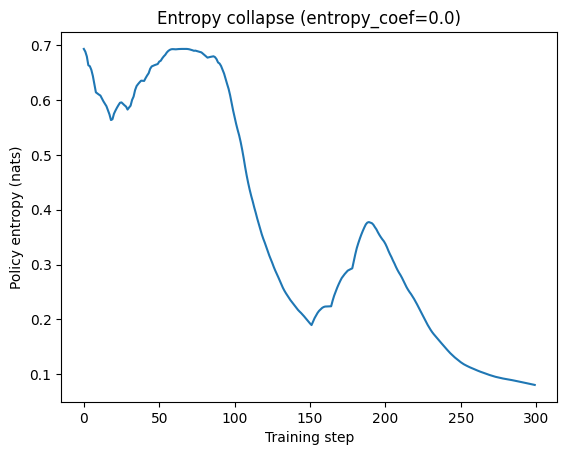

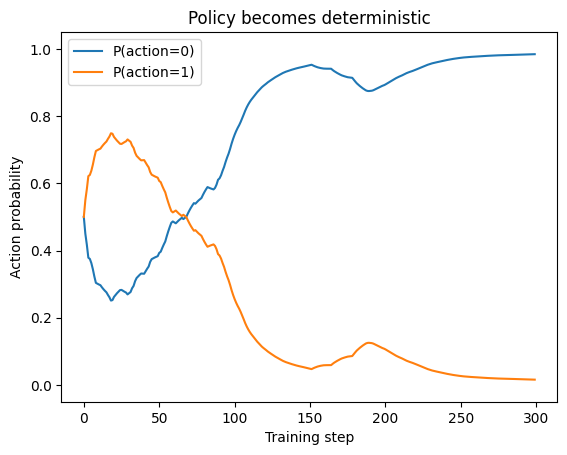

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# 2-armed bandit environment
# ----------------------------
# Action 0 is slightly better than action 1
p_reward = torch.tensor([0.55, 0.45], device=device)

def step_bandit(action: torch.Tensor) -> torch.Tensor:
    """Bernoulli reward with action-dependent probability."""
    probs = p_reward[action]
    return torch.bernoulli(probs)

# ----------------------------
# Policy: logits over 2 actions
# ----------------------------
class Policy(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(n_actions))

    def forward(self):
        return self.logits

policy = Policy().to(device)
opt = torch.optim.Adam(policy.parameters(), lr=0.1)

# ----------------------------
# Train with REINFORCE
# ----------------------------
T = 300
entropy_coef = 0.0   # <-- set to >0.0 to PREVENT entropy collapse

ent_hist = []
p0_hist = []
p1_hist = []

for t in range(T):
    logits = policy()
    dist = torch.distributions.Categorical(logits=logits)
    action = dist.sample()
    reward = step_bandit(action)

    # REINFORCE loss: -E[reward * log pi(a)]
    logp = dist.log_prob(action)
    entropy = dist.entropy()  # scalar

    loss = -(reward * logp) - entropy_coef * entropy

    opt.zero_grad()
    loss.backward()
    opt.step()

    with torch.no_grad():
        probs = dist.probs
        ent_hist.append(entropy.item())
        p0_hist.append(probs[0].item())
        p1_hist.append(probs[1].item())

# ----------------------------
# Visualize entropy collapse
# ----------------------------
plt.figure()
plt.plot(ent_hist)
plt.xlabel("Training step")
plt.ylabel("Policy entropy (nats)")
plt.title(f"Entropy collapse (entropy_coef={entropy_coef})")
plt.show()

plt.figure()
plt.plot(p0_hist, label="P(action=0)")
plt.plot(p1_hist, label="P(action=1)")
plt.xlabel("Training step")
plt.ylabel("Action probability")
plt.title("Policy becomes deterministic")
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

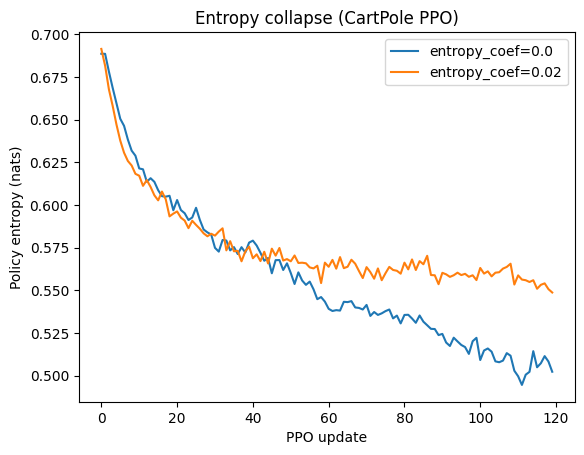

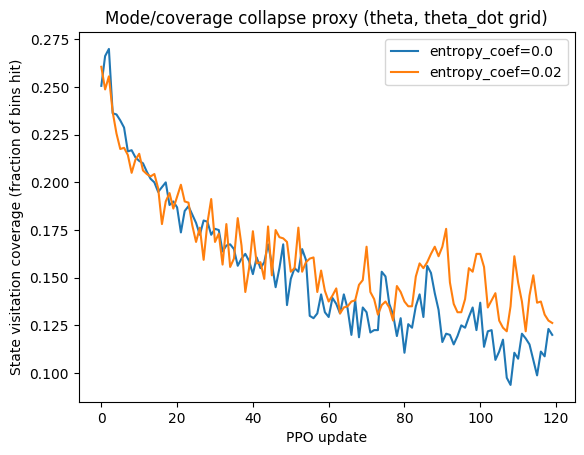

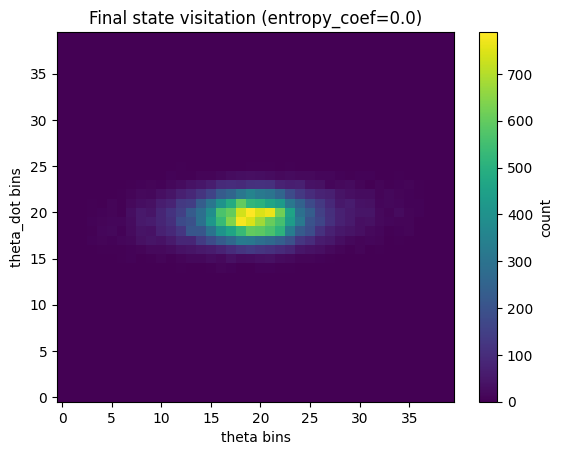

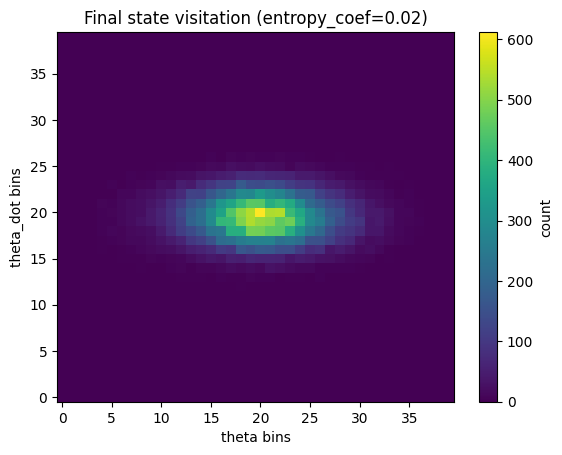

Final coverage A: 0.12 Final entropy A: 0.502289891242981
Final coverage B: 0.12625 Final entropy B: 0.5487331748008728


In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym

# ----------------------------
# Utilities
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

def explained_variance(y_pred, y_true):
    var_y = torch.var(y_true)
    return float(1 - torch.var(y_true - y_pred) / (var_y + 1e-8))

# ----------------------------
# Actor-Critic
# ----------------------------
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.pi = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )
        self.v  = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def dist(self, obs):
        logits = self.pi(obs)
        return torch.distributions.Categorical(logits=logits)

    def value(self, obs):
        return self.v(obs).squeeze(-1)

# ----------------------------
# Rollout buffer
# ----------------------------
class Rollout:
    def __init__(self, T, N, obs_dim):
        self.obs   = torch.zeros(T, N, obs_dim, device=device)
        self.act   = torch.zeros(T, N, dtype=torch.long, device=device)
        self.logp  = torch.zeros(T, N, device=device)
        self.rew   = torch.zeros(T, N, device=device)
        self.done  = torch.zeros(T, N, device=device)
        self.val   = torch.zeros(T, N, device=device)

    def compute_gae(self, last_val, gamma=0.99, lam=0.95):
        T, N = self.rew.shape
        adv = torch.zeros(T, N, device=device)
        last_gae = torch.zeros(N, device=device)
        for t in reversed(range(T)):
            next_nonterminal = 1.0 - self.done[t]
            next_value = last_val if t == T-1 else self.val[t+1]
            delta = self.rew[t] + gamma * next_value * next_nonterminal - self.val[t]
            last_gae = delta + gamma * lam * next_nonterminal * last_gae
            adv[t] = last_gae
        ret = adv + self.val
        return adv, ret

# ----------------------------
# State visitation / "mode coverage"
# ----------------------------
def visitation_metrics(states_np, bins=(40, 40), ranges=((-0.25, 0.25), (-3.0, 3.0)), thresh=3):
    """
    Use (theta, theta_dot) projection:
      states_np shape: (num_steps, 4) = [x, x_dot, theta, theta_dot]
    Returns:
      H: histogram
      coverage: fraction of bins with count >= thresh
    """
    theta = states_np[:, 2]
    thdot = states_np[:, 3]
    H, xedges, yedges = np.histogram2d(theta, thdot, bins=bins, range=ranges)
    coverage = float((H >= thresh).sum() / H.size)
    return H, coverage

# ----------------------------
# PPO training function
# ----------------------------
def train_ppo_cartpole(
    seed=0,
    entropy_coef=0.0,
    total_updates=120,
    T=256,
    N=16,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    vf_coef=0.5,
    lr=2.5e-4,
    epochs=4,
    mb_size=1024,
):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)

    envs = gym.vector.SyncVectorEnv([lambda: gym.make("CartPole-v1") for _ in range(N)])
    obs_dim = envs.single_observation_space.shape[0]
    act_dim = envs.single_action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-5)

    obs, _ = envs.reset(seed=seed)
    obs = torch.tensor(obs, dtype=torch.float32, device=device)

    # Logs
    ent_log = []
    ret_log = []
    cov_log = []

    # For final visitation plot: store one large batch of states near end
    final_states = []

    for update in range(total_updates):
        roll = Rollout(T, N, obs_dim)
        ep_returns = np.zeros(N, dtype=np.float32)

        # collect rollout
        states_for_cov = []

        for t in range(T):
            roll.obs[t] = obs
            with torch.no_grad():
                dist = model.dist(obs)
                val  = model.value(obs)
                act  = dist.sample()
                logp = dist.log_prob(act)
            roll.act[t] = act
            roll.logp[t] = logp
            roll.val[t] = val

            next_obs, rew, term, trunc, _ = envs.step(act.cpu().numpy())
            done = np.logical_or(term, trunc)

            roll.rew[t] = torch.tensor(rew, dtype=torch.float32, device=device)
            roll.done[t] = torch.tensor(done.astype(np.float32), device=device)

            # track returns for a crude "reward trending"
            ep_returns += rew
            ep_returns[done] = 0.0

            # store states for coverage metric (use raw numpy obs)
            states_for_cov.append(next_obs.copy())

            obs = torch.tensor(next_obs, dtype=torch.float32, device=device)

        with torch.no_grad():
            last_val = model.value(obs)

        adv, ret = roll.compute_gae(last_val, gamma=gamma, lam=lam)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Log mean entropy on the rollout (pre-update)
        with torch.no_grad():
            dist0 = model.dist(roll.obs.reshape(-1, obs_dim))
            ent = dist0.entropy().mean().item()
        ent_log.append(ent)

        # Coverage on this rollout (theta, theta_dot)
        states_for_cov = np.concatenate(states_for_cov, axis=0)  # (T*N, 4)
        _, cov = visitation_metrics(states_for_cov)
        cov_log.append(cov)

        # Save some late states for final heatmap
        if update > total_updates - 10:
            final_states.append(states_for_cov)

        # PPO update
        B = T * N
        flat_obs  = roll.obs.reshape(B, obs_dim)
        flat_act  = roll.act.reshape(B)
        flat_logp = roll.logp.reshape(B)
        flat_ret  = ret.reshape(B)
        flat_adv  = adv.reshape(B)

        idxs = np.arange(B)
        for _ in range(epochs):
            rng.shuffle(idxs)
            for start in range(0, B, mb_size):
                mb = idxs[start:start+mb_size]
                mb_obs = flat_obs[mb]
                mb_act = flat_act[mb]
                mb_oldlogp = flat_logp[mb]
                mb_ret = flat_ret[mb]
                mb_adv = flat_adv[mb]

                dist = model.dist(mb_obs)
                newlogp = dist.log_prob(mb_act)
                entropy = dist.entropy().mean()

                ratio = (newlogp - mb_oldlogp).exp()
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * mb_adv
                pi_loss = -torch.min(surr1, surr2).mean()

                v = model.value(mb_obs)
                vf_loss = F.mse_loss(v, mb_ret)

                loss = pi_loss + vf_coef * vf_loss - entropy_coef * entropy

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt.step()

        # quick approximate performance metric: average value explained variance
        with torch.no_grad():
            v_pred = model.value(flat_obs)
            ev = explained_variance(v_pred, flat_ret)
        ret_log.append(ev)

    envs.close()

    final_states = np.concatenate(final_states, axis=0) if len(final_states) else states_for_cov
    H, cov_final = visitation_metrics(final_states)

    return {
        "entropy": np.array(ent_log),
        "coverage": np.array(cov_log),
        "ev": np.array(ret_log),
        "final_hist": H,
        "final_states": final_states,
        "entropy_coef": entropy_coef,
    }

# ----------------------------
# Run two trainings
# ----------------------------
run_A = train_ppo_cartpole(seed=0, entropy_coef=0.0)    # likely entropy collapse
run_B = train_ppo_cartpole(seed=1, entropy_coef=0.02)   # encourages exploration / less collapse

# ----------------------------
# Plots: entropy + coverage ("mode" proxy)
# ----------------------------
plt.figure()
plt.plot(run_A["entropy"], label="entropy_coef=0.0")
plt.plot(run_B["entropy"], label="entropy_coef=0.02")
plt.xlabel("PPO update")
plt.ylabel("Policy entropy (nats)")
plt.title("Entropy collapse (CartPole PPO)")
plt.legend()
plt.show()

plt.figure()
plt.plot(run_A["coverage"], label="entropy_coef=0.0")
plt.plot(run_B["coverage"], label="entropy_coef=0.02")
plt.xlabel("PPO update")
plt.ylabel("State visitation coverage (fraction of bins hit)")
plt.title("Mode/coverage collapse proxy (theta, theta_dot grid)")
plt.legend()
plt.show()

# ----------------------------
# State visitation heatmaps (final)
# ----------------------------
def show_heatmap(H, title):
    plt.figure()
    plt.imshow(H.T, origin="lower", aspect="auto")
    plt.title(title)
    plt.xlabel("theta bins")
    plt.ylabel("theta_dot bins")
    plt.colorbar(label="count")
    plt.show()

show_heatmap(run_A["final_hist"], "Final state visitation (entropy_coef=0.0)")
show_heatmap(run_B["final_hist"], "Final state visitation (entropy_coef=0.02)")

print("Final coverage A:", run_A["coverage"][-1], "Final entropy A:", run_A["entropy"][-1])
print("Final coverage B:", run_B["coverage"][-1], "Final entropy B:", run_B["entropy"][-1])

checkpoint update=  1  entropy=0.689  mean_return=24.9
checkpoint update= 10  entropy=0.628  mean_return=64.9
checkpoint update= 20  entropy=0.604  mean_return=130.5
checkpoint update= 30  entropy=0.583  mean_return=218.4
checkpoint update= 40  entropy=0.566  mean_return=204.0
checkpoint update= 50  entropy=0.552  mean_return=202.8
checkpoint update= 60  entropy=0.541  mean_return=288.8
checkpoint update= 70  entropy=0.542  mean_return=194.0
checkpoint update= 80  entropy=0.533  mean_return=246.0
checkpoint update=  1  entropy=0.690  mean_return=26.4
checkpoint update= 10  entropy=0.637  mean_return=67.8
checkpoint update= 20  entropy=0.611  mean_return=149.2
checkpoint update= 30  entropy=0.589  mean_return=217.1
checkpoint update= 40  entropy=0.570  mean_return=231.5
checkpoint update= 50  entropy=0.557  mean_return=187.2
checkpoint update= 60  entropy=0.551  mean_return=269.2
checkpoint update= 70  entropy=0.549  mean_return=246.4
checkpoint update= 80  entropy=0.541  mean_return=22

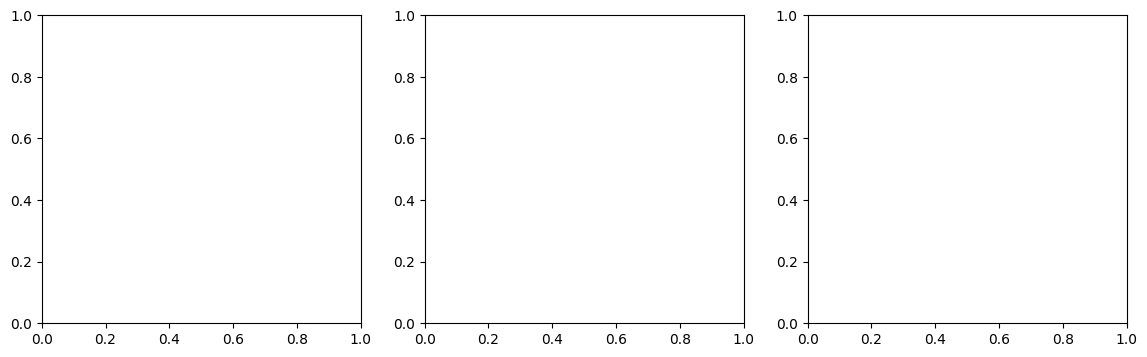

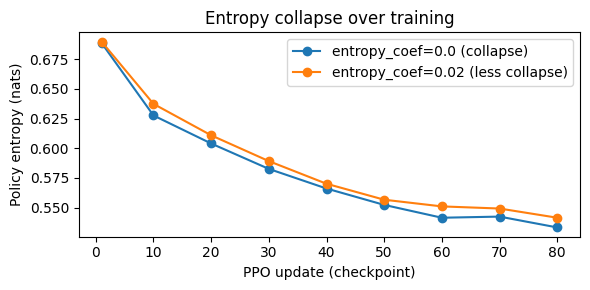

<Figure size 640x480 with 0 Axes>

In [ ]:
# COMPLETE Colab cell:
# ✅ Train CartPole PPO
# ✅ Collect trajectory embeddings over time (checkpoints)
# ✅ Compute PH (H0/H1) on embeddings at each checkpoint
# ✅ Render an in-cell "topology evolution movie" (no mp4) showing PPO collapse
#
# Run this cell end-to-end in Colab.

!pip -q install gymnasium[classic-control] ripser persim scikit-learn scipy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from ripser import ripser

# ----------------------------
# Repro + device
# ----------------------------
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Actor-Critic (Categorical policy)
# ----------------------------
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.pi = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )
        self.v = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def dist(self, obs):
        logits = self.pi(obs)
        return torch.distributions.Categorical(logits=logits)

    def value(self, obs):
        return self.v(obs).squeeze(-1)

# ----------------------------
# Rollout buffer + GAE
# ----------------------------
class Rollout:
    def __init__(self, T, N, obs_dim):
        self.obs  = torch.zeros(T, N, obs_dim, device=device)
        self.act  = torch.zeros(T, N, dtype=torch.long, device=device)
        self.logp = torch.zeros(T, N, device=device)
        self.rew  = torch.zeros(T, N, device=device)
        self.done = torch.zeros(T, N, device=device)
        self.val  = torch.zeros(T, N, device=device)

    def gae(self, last_val, gamma=0.99, lam=0.95):
        T, N = self.rew.shape
        adv = torch.zeros(T, N, device=device)
        last_gae = torch.zeros(N, device=device)
        for t in reversed(range(T)):
            next_nonterminal = 1.0 - self.done[t]
            next_value = last_val if t == T-1 else self.val[t+1]
            delta = self.rew[t] + gamma * next_value * next_nonterminal - self.val[t]
            last_gae = delta + gamma * lam * next_nonterminal * last_gae
            adv[t] = last_gae
        ret = adv + self.val
        return adv, ret

# ----------------------------
# Trajectory embedding: flatten a subsampled (theta, theta_dot) time-series
# ----------------------------
def collect_trajectory_embeddings(model, n_traj=64, max_steps=500, stride=5):
    """
    Returns:
      E: (n_traj, D) embedding vectors where D = 2 * ceil(max_steps/stride)
      R: (n_traj,) episode returns
    """
    env = gym.make("CartPole-v1")
    D = 2 * int(np.ceil(max_steps / stride))
    E = np.zeros((n_traj, D), dtype=np.float32)
    R = np.zeros(n_traj, dtype=np.float32)

    for i in range(n_traj):
        obs, _ = env.reset(seed=seed + 1000 + i)
        total = 0.0
        feats = []
        for t in range(max_steps):
            # extract (theta, theta_dot) from state: [x, xdot, theta, thetadot]
            if t % stride == 0:
                feats.append(obs[2])
                feats.append(obs[3])

            with torch.no_grad():
                o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                a = model.dist(o).sample().item()
            obs, rew, term, trunc, _ = env.step(a)
            total += rew
            if term or trunc:
                break

        # pad/truncate to fixed length
        feats = np.array(feats, dtype=np.float32)
        if len(feats) < D:
            feats = np.pad(feats, (0, D - len(feats)))
        else:
            feats = feats[:D]

        E[i] = feats
        R[i] = total

    env.close()
    return E, R

# ----------------------------
# PH helpers
# ----------------------------
def compute_ph_on_embeddings(E, pca_dim=2, maxdim=1):
    """
    PCA -> 2D point cloud -> ripser PH
    Returns:
      X2: (n,2) point cloud
      dgms: list of diagrams [H0, H1]
    """
    X2 = PCA(n_components=pca_dim, random_state=0).fit_transform(E)
    X2 = (X2 - X2.mean(0)) / (X2.std(0) + 1e-8)
    dgms = ripser(X2, maxdim=maxdim)["dgms"]
    return X2, dgms

def lifetimes(diag):
    if diag is None or len(diag) == 0:
        return np.array([], dtype=np.float32)
    b, d = diag[:,0], diag[:,1]
    finite = np.isfinite(d)
    return (d[finite] - b[finite]).astype(np.float32)

# ----------------------------
# PPO training with checkpoints
# ----------------------------
def train_ppo_with_ph_checkpoints(
    entropy_coef=0.0,             # set 0.0 to encourage entropy collapse
    total_updates=80,
    checkpoint_every=10,          # collect PH every N updates
    T=256,
    N=16,
    lr=2.5e-4,
    epochs=4,
    mb_size=1024,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    vf_coef=0.5,
):
    envs = gym.vector.SyncVectorEnv([lambda: gym.make("CartPole-v1") for _ in range(N)])
    obs_dim = envs.single_observation_space.shape[0]
    act_dim = envs.single_action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-5)

    obs, _ = envs.reset(seed=seed)
    obs = torch.tensor(obs, dtype=torch.float32, device=device)

    # checkpoint storage
    ckpt_X2 = []         # list of (n_points, 2)
    ckpt_dgms = []       # list of diagrams
    ckpt_entropy = []    # scalar
    ckpt_return = []     # mean return over sampled trajectories
    ckpt_step = []       # update index

    for update in range(1, total_updates + 1):
        roll = Rollout(T, N, obs_dim)

        # rollout collection
        for t in range(T):
            roll.obs[t] = obs
            with torch.no_grad():
                dist = model.dist(obs)
                val  = model.value(obs)
                act  = dist.sample()
                logp = dist.log_prob(act)
            roll.act[t] = act
            roll.logp[t] = logp
            roll.val[t] = val

            next_obs, rew, term, trunc, _ = envs.step(act.cpu().numpy())
            done = np.logical_or(term, trunc)
            roll.rew[t]  = torch.tensor(rew, dtype=torch.float32, device=device)
            roll.done[t] = torch.tensor(done.astype(np.float32), device=device)

            obs = torch.tensor(next_obs, dtype=torch.float32, device=device)

        with torch.no_grad():
            last_val = model.value(obs)

        adv, ret = roll.gae(last_val, gamma=gamma, lam=lam)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # log mean policy entropy on rollout pre-update
        with torch.no_grad():
            dist0 = model.dist(roll.obs.reshape(-1, obs_dim))
            ent = float(dist0.entropy().mean().item())

        # PPO update
        B = T * N
        flat_obs  = roll.obs.reshape(B, obs_dim)
        flat_act  = roll.act.reshape(B)
        flat_logp = roll.logp.reshape(B)
        flat_ret  = ret.reshape(B)
        flat_adv  = adv.reshape(B)

        idxs = np.arange(B)
        for _ in range(epochs):
            np.random.shuffle(idxs)
            for start in range(0, B, mb_size):
                mb = idxs[start:start+mb_size]
                mb_obs = flat_obs[mb]
                mb_act = flat_act[mb]
                mb_oldlogp = flat_logp[mb]
                mb_ret = flat_ret[mb]
                mb_adv = flat_adv[mb]

                dist = model.dist(mb_obs)
                newlogp = dist.log_prob(mb_act)
                entropy = dist.entropy().mean()

                ratio = (newlogp - mb_oldlogp).exp()
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * mb_adv
                pi_loss = -torch.min(surr1, surr2).mean()

                v = model.value(mb_obs)
                vf_loss = F.mse_loss(v, mb_ret)

                loss = pi_loss + vf_coef * vf_loss - entropy_coef * entropy

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt.step()

        # checkpoint: collect trajectory embeddings + PH
        if update % checkpoint_every == 0 or update == 1:
            E, R = collect_trajectory_embeddings(model, n_traj=64, max_steps=500, stride=5)
            X2, dgms = compute_ph_on_embeddings(E, pca_dim=2, maxdim=1)

            ckpt_X2.append(X2)
            ckpt_dgms.append(dgms)
            ckpt_entropy.append(ent)
            ckpt_return.append(float(R.mean()))
            ckpt_step.append(update)

            print(f"checkpoint update={update:3d}  entropy={ent:.3f}  mean_return={float(R.mean()):.1f}")

    envs.close()

    return {
        "X2": ckpt_X2,
        "dgms": ckpt_dgms,
        "entropy": np.array(ckpt_entropy),
        "mean_return": np.array(ckpt_return),
        "steps": np.array(ckpt_step),
        "entropy_coef": entropy_coef,
    }

# ----------------------------
# Run two trainings: collapsed vs less-collapsed
# ----------------------------
# A: encourages entropy collapse (no entropy bonus)
runA = train_ppo_with_ph_checkpoints(entropy_coef=0.0, total_updates=80, checkpoint_every=10)

# B: higher entropy bonus (less collapse)
runB = train_ppo_with_ph_checkpoints(entropy_coef=0.02, total_updates=80, checkpoint_every=10)

# ----------------------------
# Build an in-cell "topology evolution movie"
# We show ONE run at a time; choose which here:
# ----------------------------
RUN = runA  # switch to runB to compare
title_run = f"CartPole PPO Topology Evolution (entropy_coef={RUN['entropy_coef']})"

X2_list = RUN["X2"]
dgms_list = RUN["dgms"]
ent_list = RUN["entropy"]
ret_list = RUN["mean_return"]
steps = RUN["steps"]

# We'll animate over checkpoints (training time), and within each frame show:
#  - Left: trajectory embedding scatter (PCA2)
#  - Mid: H0 diagram (birth-death scatter)
#  - Right: H1 life/death bar chart (top persistent loops), with birth/death labels
#
# Note: H0 in ripser always has one infinite death (the final component). We'll ignore that for bar charting.

def top_k_features(diag, k=12):
    if diag is None or len(diag) == 0:
        return np.zeros((0,2), dtype=np.float32)
    b, d = diag[:,0], diag[:,1]
    finite = np.isfinite(d)
    diag = diag[finite]
    if len(diag) == 0:
        return diag
    L = (diag[:,1] - diag[:,0])
    idx = np.argsort(L)[::-1][:min(k, len(diag))]
    top = diag[idx]
    top = top[np.argsort(top[:,0])]
    return top

# Precompute axis limits for stable animation
all_pts = np.concatenate(X2_list, axis=0)
xlim = (all_pts[:,0].min()*1.1, all_pts[:,0].max()*1.1)
ylim = (all_pts[:,1].min()*1.1, all_pts[:,1].max()*1.1)

# For persistence diagram axis limits (H0/H1)
def diag_limits(dgms_list):
    mx = 0.0
    for dgms in dgms_list:
        for dd in dgms[:2]:
            if dd is None or len(dd)==0:
                continue
            finite = np.isfinite(dd[:,1])
            if finite.any():
                mx = max(mx, float(dd[finite,1].max()))
            mx = max(mx, float(dd[:,0].max()))
    return (0.0, mx*1.05 if mx>0 else 1.0)

pd_lim = diag_limits(dgms_list)

fig = plt.figure(figsize=(14, 4))
ax_sc = plt.subplot(1, 3, 1)
ax_h0 = plt.subplot(1, 3, 2)
ax_h1 = plt.subplot(1, 3, 3)

def plot_persistence_diagram(ax, diag, title):
    ax.clear()
    ax.set_title(title)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_xlim(pd_lim)
    ax.set_ylim(pd_lim)
    # diagonal
    ax.plot([pd_lim[0], pd_lim[1]], [pd_lim[0], pd_lim[1]], linestyle="--", linewidth=1)

    if diag is None or len(diag) == 0:
        ax.text(0.5, 0.5, "no features", ha="center", va="center", transform=ax.transAxes)
        return

    # plot finite points (ignore infinite deaths for display)
    finite = np.isfinite(diag[:,1])
    ax.scatter(diag[finite,0], diag[finite,1], s=25, alpha=0.8)

def update(frame):
    X2 = X2_list[frame]
    dgms = dgms_list[frame]
    ent = ent_list[frame]
    mr  = ret_list[frame]
    step = steps[frame]

    # ---- Left: trajectory embedding point cloud ----
    ax_sc.clear()
    ax_sc.scatter(X2[:,0], X2[:,1], s=20, alpha=0.75)
    ax_sc.set_xlim(xlim)
    ax_sc.set_ylim(ylim)
    ax_sc.set_title(f"{title_run}\ncheckpoint update={step}  entropy={ent:.3f}  mean_return={mr:.1f}")
    ax_sc.set_xlabel("PCA-1")
    ax_sc.set_ylabel("PCA-2")

    # ---- Middle: H0 persistence diagram ----
    plot_persistence_diagram(ax_h0, dgms[0], "H0 persistence (components)")

    # ---- Right: H1 life/death bar chart with labels ----
    ax_h1.clear()
    ax_h1.set_title("H1 life/death intervals (top persistent loops)")
    ax_h1.set_xlabel("ε (scale)")
    ax_h1.set_ylabel("loop index")

    H1_top = top_k_features(dgms[1], k=12)
    if len(H1_top) == 0:
        ax_h1.text(0.5, 0.5, "no H1 features", ha="center", va="center", transform=ax_h1.transAxes)
        ax_h1.set_yticks([])
        ax_h1.set_xlim(0, 1)
    else:
        births = H1_top[:,0]
        deaths = H1_top[:,1]
        widths = deaths - births
        y = np.arange(len(H1_top))

        # bar plot
        for i in range(len(H1_top)):
            ax_h1.barh(y[i], widths[i], left=births[i], alpha=0.7)
            # birth/death labels
            ax_h1.text(float(births[i]), y[i] + 0.15, f"{births[i]:.3f}", ha="left", va="bottom", fontsize=8)
            ax_h1.text(float(deaths[i]), y[i] + 0.15, f"{deaths[i]:.3f}", ha="right", va="bottom", fontsize=8)

        ax_h1.set_yticks(y)
        ax_h1.set_yticklabels([f"loop {i}" for i in y])
        ax_h1.set_xlim(0.0, float(max(deaths.max(), 1e-6)) * 1.05)

    plt.tight_layout()
    return []

ani = FuncAnimation(fig, update, frames=len(X2_list), interval=900, repeat=True)

# Also show entropy trajectories for both runs (static) so you can see collapse
plt.figure(figsize=(6,3))
plt.plot(runA["steps"], runA["entropy"], marker="o", label="entropy_coef=0.0 (collapse)")
plt.plot(runB["steps"], runB["entropy"], marker="o", label="entropy_coef=0.02 (less collapse)")
plt.xlabel("PPO update (checkpoint)")
plt.ylabel("Policy entropy (nats)")
plt.title("Entropy collapse over training")
plt.legend()
plt.tight_layout()
plt.show()

HTML(ani.to_jshtml())


[entropy_coef=0.0] no collapse start detected with this heuristic.


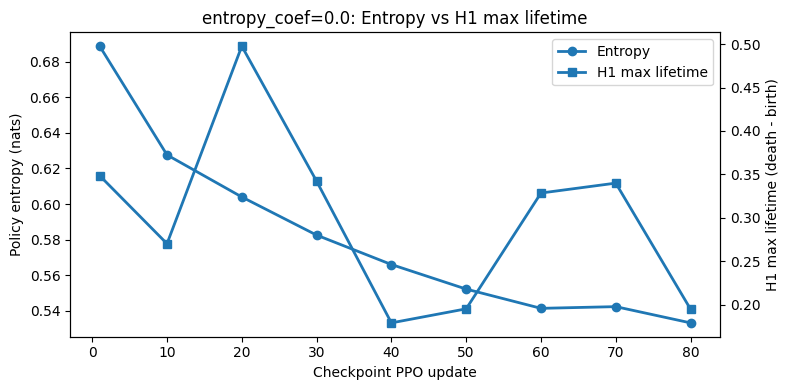

[entropy_coef=0.02] no collapse start detected with this heuristic.


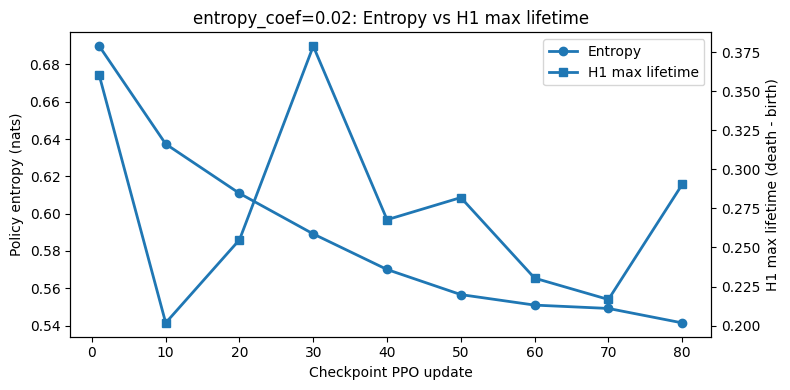

(array([ 1, 10, 20, 30, 40, 50, 60, 70, 80]),
 array([0.68978608, 0.63733333, 0.61085147, 0.58910465, 0.57003832,
        0.55657601, 0.55094683, 0.54915375, 0.54141068]),
 array([0.36017346, 0.2017087 , 0.25494778, 0.37895626, 0.26779878,
        0.28198862, 0.23036146, 0.21669364, 0.2903894 ], dtype=float32))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def h1_max_lifetime(dgms):
    """
    dgms = list where dgms[1] is H1 diagram (birth, death).
    Returns max finite lifetime in H1.
    """
    H1 = dgms[1]
    if H1 is None or len(H1) == 0:
        return 0.0
    b = H1[:, 0]
    d = H1[:, 1]
    finite = np.isfinite(d)
    if not np.any(finite):
        return 0.0
    L = d[finite] - b[finite]
    return float(np.max(L)) if len(L) else 0.0

def compute_series(run):
    steps = np.array(run["steps"])
    ent   = np.array(run["entropy"])
    h1max = np.array([h1_max_lifetime(dg) for dg in run["dgms"]], dtype=np.float32)
    return steps, ent, h1max

def detect_collapse_start(steps, ent, h1max, w=3, ent_frac=0.5, h1_frac=0.5):
    """
    Heuristic "collapse begins" detector:
      - compare moving-avg entropy and H1max to early baseline (first 3 checkpoints)
      - find first checkpoint where BOTH:
          ent_ma < ent_frac * ent_baseline
          h1_ma  < h1_frac  * h1_baseline
    Returns: index (int) or None
    """
    if len(steps) < 6:
        return None

    # Early baseline from first few checkpoints
    b = min(3, len(steps))
    ent_base = float(np.mean(ent[:b]))
    h1_base  = float(np.mean(h1max[:b]))

    # Moving averages (simple)
    def movavg(x, w):
        y = np.copy(x).astype(np.float32)
        for i in range(len(x)):
            lo = max(0, i - w + 1)
            y[i] = np.mean(x[lo:i+1])
        return y

    ent_ma = movavg(ent, w)
    h1_ma  = movavg(h1max, w)

    ent_thr = ent_frac * ent_base
    h1_thr  = h1_frac  * h1_base

    for i in range(len(steps)):
        if ent_ma[i] < ent_thr and h1_ma[i] < h1_thr:
            return i, ent_base, h1_base, ent_thr, h1_thr, ent_ma, h1_ma
    return None

def plot_overlay(run, name="run", w=3, ent_frac=0.5, h1_frac=0.5):
    steps, ent, h1max = compute_series(run)

    det = detect_collapse_start(steps, ent, h1max, w=w, ent_frac=ent_frac, h1_frac=h1_frac)

    fig, ax1 = plt.subplots(figsize=(8,4))
    ax2 = ax1.twinx()

    # Plot entropy (left y)
    ax1.plot(steps, ent, marker="o", label="Entropy", linewidth=2)
    ax1.set_xlabel("Checkpoint PPO update")
    ax1.set_ylabel("Policy entropy (nats)")

    # Plot H1 max lifetime (right y)
    ax2.plot(steps, h1max, marker="s", label="H1 max lifetime", linewidth=2)
    ax2.set_ylabel("H1 max lifetime (death - birth)")

    # Legends (combine)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    title = f"{name}: Entropy vs H1 max lifetime"
    ax1.set_title(title)

    # Annotate collapse start if detected
    if det is not None:
        i, ent_base, h1_base, ent_thr, h1_thr, ent_ma, h1_ma = det
        cs = steps[i]

        ax1.axvline(cs, linestyle="--", linewidth=2)
        ax1.text(
            cs, ax1.get_ylim()[1]*0.95,
            f"collapse starts @ update={int(cs)}",
            rotation=90, va="top", ha="right"
        )

        # print a little report
        print(f"[{name}] baseline entropy≈{ent_base:.3f}, baseline H1max≈{h1_base:.3f}")
        print(f"[{name}] thresholds: entropy<{ent_thr:.3f} and H1max<{h1_thr:.3f}")
        print(f"[{name}] collapse begins at checkpoint update={int(cs)}")
        print(f"[{name}] values there: entropy={ent[i]:.3f}, H1max={h1max[i]:.3f}")
    else:
        print(f"[{name}] no collapse start detected with this heuristic.")

    plt.tight_layout()
    plt.show()

    return steps, ent, h1max

# ---- Run on your saved objects ----
# Assumes you already have runA and runB dicts from the earlier code.
plot_overlay(runA, name="entropy_coef=0.0", w=3, ent_frac=0.5, h1_frac=0.5)
plot_overlay(runB, name="entropy_coef=0.02", w=3, ent_frac=0.5, h1_frac=0.5)